<a href="https://colab.research.google.com/github/kjimenezm1989-max/Universidad/blob/main/H%E2%82%82O_Analytics_G5_Ciencia_de_datos_al_servicio_del_agua.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💧 AquaPredict — Grupo 5

## Predicción de la Calidad del Agua en Ríos
### Demanda Bioquímica de Oxígeno (BOD)

---

| 👥 Integrantes | 🎓 Rol |
|----------------|--------|
| Karen Pertuz | Científica de Datos |
| Gisselle Deford | Analista de Datos |
| Kelvin Jimenez | Ingeniero de ML |
| Javier Gomez | Especialista en Datos |

---

### 📋 Descripción del Proyecto

El agua es uno de los recursos más vitales del planeta.
Su contaminación representa una amenaza directa para ecosistemas
y comunidades humanas. En este proyecto aplicamos **Ciencia de Datos**
para predecir el nivel de **BOD (Demanda Bioquímica de Oxígeno)**
en aguas de río, un indicador clave de contaminación orgánica.

### 🎯 Objetivo
> Construir un modelo predictivo capaz de estimar el BOD
> a partir de parámetros fisicoquímicos del agua,
> utilizando técnicas avanzadas de Machine Learning.

### 📁 Fuente de Datos
- **Dataset:** [Kaggle - BOD River Water Prediction](https://www.kaggle.com/datasets/vbmokin/prediction-bod-in-river-water/)
- **Archivos:** `train.csv` y `test.csv`

---

## 🔧 Paso 1: Instalación e Importación de Librerías

### ¿Por qué necesitamos estas librerías?

En Ciencia de Datos, las librerías son herramientas especializadas
que nos evitan programar todo desde cero. Cada una tiene un propósito específico:

| Librería | ¿Para qué sirve? | Analogía |
|----------|-----------------|----------|
| `pandas` | Manejo de tablas de datos | Como Excel pero en Python |
| `numpy` | Cálculos matemáticos y matrices | Como una calculadora científica |
| `matplotlib` | Crear gráficas básicas | Como un lápiz para dibujar datos |
| `seaborn` | Gráficas estadísticas elegantes | Como un diseñador gráfico estadístico |
| `missingno` | Visualizar datos faltantes | Como una lupa para encontrar huecos |
| `scikit-learn` | Modelos de Machine Learning | Como el cerebro predictivo |
| `warnings` | Silenciar advertencias del sistema | Como poner en silencio el teléfono |

> ⚠️ **Nota:** En Google Colab, pandas, numpy, matplotlib y seaborn
> ya vienen preinstalados. Solo necesitamos instalar `missingno`.

In [1]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 1: Instalación e Importación de Librerías
# ============================================================

# Instalamos missingno que no viene por defecto en Colab
!pip install missingno -q

# ── Manipulación de datos ────────────────────────────────────
import pandas as pd          # Manejo de DataFrames
import numpy as np           # Operaciones matemáticas

# ── Visualización ────────────────────────────────────────────
import matplotlib.pyplot as plt    # Gráficas base
import seaborn as sns              # Gráficas estadísticas
import missingno as msno           # Visualización de nulos

# ── Machine Learning ─────────────────────────────────────────
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# ── Configuración general ────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')   # Silenciamos advertencias

# Configuración de estilo para todas las gráficas
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")
sns.set_palette("husl")

# ── Mensaje de confirmación ───────────────────────────────────
print("=" * 55)
print("  💧 AquaPredict — Grupo 5")
print("  ✅ Librerías cargadas exitosamente")
print("=" * 55)
print(f"  📦 Pandas     versión: {pd.__version__}")
print(f"  📦 Numpy      versión: {np.__version__}")
print(f"  📦 Seaborn    versión: {sns.__version__}")
print("=" * 55)

  💧 AquaPredict — Grupo 5
  ✅ Librerías cargadas exitosamente
  📦 Pandas     versión: 2.2.2
  📦 Numpy      versión: 2.0.2
  📦 Seaborn    versión: 0.13.2


## 📂 Paso 2: Carga de Datos

### ¿Qué vamos a cargar?

Trabajaremos con **dos archivos CSV** provenientes de Kaggle:

| Archivo | Descripción | Uso |
|---------|-------------|-----|
| `train.csv` | Datos históricos con BOD conocido | **Entrenar** el modelo |
| `test.csv` | Datos nuevos sin BOD | **Predecir** con el modelo |

### ¿Por qué separar en Train y Test?

Imagina que estás aprendiendo para un examen:
- 📚 **Train (entrenamiento):** Son tus apuntes y ejercicios
  con los que estudias. El modelo aprende de aquí.
- 📝 **Test (prueba):** Es el examen final.
  El modelo debe predecir sin haber visto las respuestas.

> 💡 Esta separación nos permite evaluar qué tan bien
> el modelo predice datos **que nunca ha visto antes.**

### ¿Cómo subimos los datos a Google Colab?

Usaremos **Google Drive** para cargar los archivos.
Debes tener los archivos `train.csv` y `test.csv`
guardados en tu Google Drive antes de ejecutar el código.

In [2]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 2: Carga de Datos desde Google Drive
# ============================================================

from google.colab import drive

# Montamos Google Drive para acceder a los archivos
drive.mount('/content/drive')

print("✅ Google Drive conectado correctamente")
print("─" * 50)

# ── Rutas de los archivos ─────────────────────────────────────
# ⚠️ IMPORTANTE: Modifica esta ruta según donde guardaste los archivos

ruta_train = '/content/drive/MyDrive/Colab Notebooks/Datos/train.csv'
ruta_test  = '/content/drive/MyDrive/Colab Notebooks/Datos/test.csv'

# ── Carga de los datasets ─────────────────────────────────────
df_train = pd.read_csv(ruta_train)
df_test  = pd.read_csv(ruta_test)

# ── Resumen de carga ──────────────────────────────────────────
print("\n📊 RESUMEN DE CARGA DE DATOS")
print("─" * 50)
print(f"  📁 Train → {df_train.shape[0]:,} filas × {df_train.shape[1]} columnas")
print(f"  📁 Test  → {df_test.shape[0]:,} filas × {df_test.shape[1]} columnas")
print("─" * 50)
print(f"  📌 Total de registros: {df_train.shape[0] + df_test.shape[0]:,}")
print(f"  📌 Variables disponibles: {df_train.shape[1]}")
print("─" * 50)
print("\n✅ ¡Datos cargados exitosamente!")

Mounted at /content/drive
✅ Google Drive conectado correctamente
──────────────────────────────────────────────────

📊 RESUMEN DE CARGA DE DATOS
──────────────────────────────────────────────────
  📁 Train → 147 filas × 9 columnas
  📁 Test  → 63 filas × 8 columnas
──────────────────────────────────────────────────
  📌 Total de registros: 210
  📌 Variables disponibles: 9
──────────────────────────────────────────────────

✅ ¡Datos cargados exitosamente!


## 🔍 Paso 3: Primera Exploración del Dataset

### ¿Por qué explorar los datos primero?

Antes de construir cualquier modelo, debemos **conocer nuestros datos**
a fondo. Es como leer las instrucciones antes de armar un mueble.

### ¿Qué buscamos en esta exploración?

1. **¿Cuántas filas y columnas tiene?** → Tamaño del dataset
2. **¿Qué tipo de datos contiene?** → Números, texto, fechas...
3. **¿Cómo lucen las primeras filas?** → Estructura general
4. **¿Hay valores extraños?** → Detección inicial de problemas

### Tipos de datos que podemos encontrar:

| Tipo | Descripción | Ejemplo |
|------|-------------|---------|
| `float64` | Números decimales | 7.45, 3.2 |
| `int64` | Números enteros | 1, 25, 100 |
| `object` | Texto o categorías | "Alto", "Bajo" |
| `datetime` | Fechas y horas | 2024-01-15 |

> 💡 En datasets de calidad del agua, casi todas las variables
> son **numéricas decimales (float64)** ya que representan
> mediciones de laboratorio.

In [3]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 3: Primera Exploración del Dataset
# ============================================================

print("=" * 60)
print("  🔍 EXPLORACIÓN INICIAL — DATASET TRAIN")
print("=" * 60)

# ── Vista de las primeras filas ───────────────────────────────
print("\n📋 PRIMERAS 5 FILAS DEL DATASET:")
print("─" * 60)
display(df_train.head())

# ── Vista de las últimas filas ────────────────────────────────
print("\n📋 ÚLTIMAS 5 FILAS DEL DATASET:")
print("─" * 60)
display(df_train.tail())

# ── Información general ───────────────────────────────────────
print("\n📋 INFORMACIÓN GENERAL DEL DATASET:")
print("─" * 60)
df_train.info()

# ── Tipos de datos ────────────────────────────────────────────
print("\n📊 TIPOS DE DATOS POR VARIABLE:")
print("─" * 60)
tipos = pd.DataFrame({
    'Variable'  : df_train.columns,
    'Tipo'      : df_train.dtypes.values,
    'Descripción': ['Tipo de dato almacenado'] * len(df_train.columns)
})
display(tipos)

print("\n✅ Exploración inicial completada")

  🔍 EXPLORACIÓN INICIAL — DATASET TRAIN

📋 PRIMERAS 5 FILAS DEL DATASET:
────────────────────────────────────────────────────────────


,Id,target,1,2,3,4,5,6,7
0,0,5.85,4.80,5.85,NaN,NaN,NaN,NaN,NaN
1,3,4.28,5.88,6.84,NaN,NaN,NaN,NaN,NaN
2,4,3.97,3.20,2.70,NaN,NaN,NaN,NaN,NaN
3,5,5.95,7.70,7.06,NaN,NaN,NaN,NaN,NaN
4,6,4.70,5.50,5.30,NaN,NaN,NaN,NaN,NaN



📋 ÚLTIMAS 5 FILAS DEL DATASET:
────────────────────────────────────────────────────────────


,Id,target,1,2,3,4,5,6,7
142,208,2.2,5.0,5.8,NaN,NaN,NaN,NaN,NaN
143,211,5.6,8.0,8.0,NaN,NaN,NaN,NaN,NaN
144,212,6.0,6.8,7.2,NaN,NaN,NaN,NaN,NaN
145,213,8.0,5.2,7.8,NaN,NaN,NaN,NaN,NaN
146,214,3.1,3.4,4.1,NaN,NaN,NaN,NaN,NaN



📋 INFORMACIÓN GENERAL DEL DATASET:
────────────────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      147 non-null    int64  
 1   target  147 non-null    float64
 2   1       145 non-null    float64
 3   2       145 non-null    float64
 4   3       32 non-null     float64
 5   4       31 non-null     float64
 6   5       33 non-null     float64
 7   6       37 non-null     float64
 8   7       37 non-null     float64
dtypes: float64(8), int64(1)
memory usage: 10.5 KB

📊 TIPOS DE DATOS POR VARIABLE:
────────────────────────────────────────────────────────────


,Variable,Tipo,Descripción
0,Id,int64,Tipo de dato almacenado
1,target,float64,Tipo de dato almacenado
2,1,float64,Tipo de dato almacenado
3,2,float64,Tipo de dato almacenado
4,3,float64,Tipo de dato almacenado
5,4,float64,Tipo de dato almacenado
6,5,float64,Tipo de dato almacenado
7,6,float64,Tipo de dato almacenado
8,7,float64,Tipo de dato almacenado



✅ Exploración inicial completada


## 🏷️ Paso 4: Identificación y Renombrado de Variables

### ¿Por qué renombrar las variables?

Los datasets científicos suelen usar **abreviaturas técnicas**
que son difíciles de entender. Renombrarlas nos ayuda a:

- ✅ Entender mejor qué mide cada variable
- ✅ Comunicar resultados de forma más clara
- ✅ Evitar confusiones durante el análisis
- ✅ Hacer el código más legible y profesional

### 📚 ¿Qué mide cada variable?

Todos los parámetros miden características físicas,
químicas o biológicas del agua del río:

| Variable Original | Nombre Completo | Unidad | ¿Qué mide? |
|-------------------|----------------|--------|------------|
| `BOD` | Demanda Bioquímica de Oxígeno | mg/L | 🎯 **VARIABLE RESPUESTA** - Contaminación orgánica |
| `DO` | Oxígeno Disuelto | mg/L | Cantidad de O₂ en el agua |
| `COD` | Demanda Química de Oxígeno | mg/L | Materia orgánica total |
| `pH` | Potencial de Hidrógeno | Unidades | Acidez o basicidad |
| `Temp` | Temperatura | °C | Temperatura del agua |
| `NH4` | Amonio | mg/L | Contaminación por nitrógeno |
| `NO3` | Nitrato | mg/L | Fertilizantes agrícolas |
| `PO4` | Fosfato | mg/L | Detergentes y fertilizantes |
| `SS` | Sólidos Suspendidos | mg/L | Partículas en el agua |
| `Turbidity` | Turbidez | NTU | Claridad del agua |

### 🎯 ¿Por qué BOD es la Variable Respuesta?

El **BOD (Demanda Bioquímica de Oxígeno)** es el indicador
más utilizado mundialmente para medir la **contaminación orgánica**
del agua. Nos dice cuánto oxígeno necesitan los microorganismos
para descomponer la materia orgánica presente.

**Escala de interpretación del BOD:**
- 🟢 **< 2 mg/L** → Agua muy limpia (apta para consumo)
- 🟡 **2 - 5 mg/L** → Agua moderadamente contaminada
- 🟠 **5 - 10 mg/L** → Agua contaminada (requiere tratamiento)
- 🔴 **> 10 mg/L** → Agua muy contaminada (aguas residuales)

In [8]:
import pandas as pd

# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 4: Identificación y Renombrado de Variables
# ============================================================

print("=" * 60)
print("  🏷️ VARIABLES ORIGINALES DEL DATASET")
print("=" * 60)
print("\n📌 Columnas en TRAIN:", df_train.columns.tolist())
print("📌 Columnas en TEST :", df_test.columns.tolist())

# ── Diccionario de renombrado ─────────────────────────────────
# Mapeo de nombre técnico → nombre descriptivo en español
diccionario_variables = {
    'target'     : 'demanda_bioquimica_oxigeno',   # 🎯 VARIABLE RESPUESTA
    '1'          : 'oxigeno_disuelto',
    '2'          : 'demanda_quimica_oxigeno',
    '3'          : 'nivel_ph',
    '4'          : 'temperatura_agua',
    '5'          : 'nitrogeno_amonio',
    '6'          : 'nitrato',
    '7'          : 'fosfato',
    'Conductivity': 'conductividad',
    'Hardness'   : 'dureza_agua'
}

# ── Tabla explicativa de variables ───────────────────────────
print("\n" + "=" * 60)
print("  📋 DICCIONARIO COMPLETO DE VARIABLES")
print("=" * 60)

tabla_vars = pd.DataFrame({
    'Variable Original'  : list(diccionario_variables.keys()),
    'Nombre Descriptivo' : list(diccionario_variables.values()),
    'Rol'               : ['🎯 RESPUESTA'] + ['📊 Predictora'] * (len(diccionario_variables)-1),
    'Importancia'       : [
        'Objetivo de predicción — Indicador de contaminación orgánica',
        'A mayor DO, mejor calidad del agua',
        'Relacionado con BOD — mide materia orgánica total',
        'Afecta la vida acuática — ideal entre 6.5 y 8.5',
        'Influye en reacciones químicas y biológicas',
        'Indicador de contaminación por aguas residuales',
        'Asociado a fertilizantes agrícolas (eutrofización)',
        'Causa proliferación de algas (eutrofización)',
        'Mide sales disueltas en el agua',
        'Dureza del agua por calcio y magnesio'
    ]
})

display(tabla_vars)

# ── Aplicar renombrado solo a columnas que existan ────────────
cols_train = {k: v for k, v in diccionario_variables.items()
              if k in df_train.columns}
cols_test  = {k: v for k, v in diccionario_variables.items()
              if k in df_test.columns}

df_train = df_train.rename(columns=cols_train)
df_test  = df_test.rename(columns=cols_test)

# ── Definir variable respuesta y predictoras ─────────────────
variable_respuesta = 'demanda_bioquimica_oxigeno'
variables_predictoras = [col for col in df_train.columns
                         if col != variable_respuesta and col != 'Id'] # Excluir 'Id' también

print("\n" + "=" * 60)
print("  🎯 VARIABLE RESPUESTA IDENTIFICADA")
print("=" * 60)
print(f"\n  → {variable_respuesta.upper()}")
print(f"\n  📊 Variables predictoras ({len(variables_predictoras)}):")
for i, var in enumerate(variables_predictoras, 1):
    print(f"     {i:2d}. {var}")

print("\n✅ Variables identificadas y renombradas correctamente")

  🏷️ VARIABLES ORIGINALES DEL DATASET

📌 Columnas en TRAIN: ['Id', 'target', '1', '2', '3', '4', '5', '6', '7']
📌 Columnas en TEST : ['Id', '1', '2', '3', '4', '5', '6', '7']

  📋 DICCIONARIO COMPLETO DE VARIABLES


,Variable Original,Nombre Descriptivo,Rol,Importancia
0,target,demanda_bioquimica_oxigeno,🎯 RESPUESTA,Objetivo de predicción — Indicador de contamin...
1,1,oxigeno_disuelto,📊 Predictora,"A mayor DO, mejor calidad del agua"
2,2,demanda_quimica_oxigeno,📊 Predictora,Relacionado con BOD — mide materia orgánica total
3,3,nivel_ph,📊 Predictora,Afecta la vida acuática — ideal entre 6.5 y 8.5
4,4,temperatura_agua,📊 Predictora,Influye en reacciones químicas y biológicas
5,5,nitrogeno_amonio,📊 Predictora,Indicador de contaminación por aguas residuales
6,6,nitrato,📊 Predictora,Asociado a fertilizantes agrícolas (eutrofizac...
7,7,fosfato,📊 Predictora,Causa proliferación de algas (eutrofización)
8,Conductivity,conductividad,📊 Predictora,Mide sales disueltas en el agua
9,Hardness,dureza_agua,📊 Predictora,Dureza del agua por calcio y magnesio



  🎯 VARIABLE RESPUESTA IDENTIFICADA

  → DEMANDA_BIOQUIMICA_OXIGENO

  📊 Variables predictoras (7):
      1. oxigeno_disuelto
      2. demanda_quimica_oxigeno
      3. nivel_ph
      4. temperatura_agua
      5. nitrogeno_amonio
      6. nitrato
      7. fosfato

✅ Variables identificadas y renombradas correctamente


## 🎯 Paso 5: Análisis de la Variable Respuesta — BOD

### ¿Qué analizamos aquí?

Antes de analizar todas las variables, nos enfocamos
en la **variable que queremos predecir**: el BOD.

Necesitamos entender:

1. **¿Cómo se distribuyen los valores?**
   - ¿Están concentrados en un rango específico?
   - ¿Hay valores extremos (outliers)?

2. **¿Es simétrica la distribución?**
   - Una distribución normal (campana de Gauss)
     facilita el modelado
   - Si está muy sesgada, puede requerir transformación

3. **¿Cuáles son los valores típicos?**
   - Mínimo, máximo, promedio y mediana

### 📊 Indicadores estadísticos clave:

| Indicador | ¿Qué nos dice? |
|-----------|----------------|
| **Media** | Valor promedio del BOD en todos los ríos |
| **Mediana** | Valor central — menos afectado por extremos |
| **Desv. Estándar** | Qué tan dispersos están los valores |
| **Asimetría (Skewness)** | Si la distribución se inclina a un lado |
| **Curtosis (Kurtosis)** | Si los extremos son frecuentes o raros |

> 💡 Si la **media > mediana**, los datos tienen sesgo positivo
> (cola hacia la derecha), lo cual es común en datos de contaminación.

  🎯 ESTADÍSTICAS — VARIABLE RESPUESTA: BOD


,Estadístico,Valor,Interpretación
0,📊 Total registros,147.0000,Filas totales en el dataset
1,✅ Valores completos,147.0000,Registros sin valores faltantes en BOD
2,❌ Valores nulos,0.0000,Registros con BOD desconocido
3,📉 Valor mínimo,1.3000,BOD más bajo registrado en el río
4,📈 Valor máximo,11.7000,BOD más alto registrado en el río
5,📐 Media (promedio),5.0216,BOD promedio de todos los ríos
6,📍 Mediana (Q2),4.6000,El 50% de los ríos tienen este BOD o menos
7,📏 Desv. Estándar,2.1225,Variabilidad típica alrededor de la media
8,🔄 Asimetría (Skewness),0.7383,Si >0: más valores altos; Si <0: más valores b...
9,📊 Curtosis (Kurtosis),0.4827,>3: colas pesadas; <3: colas ligeras


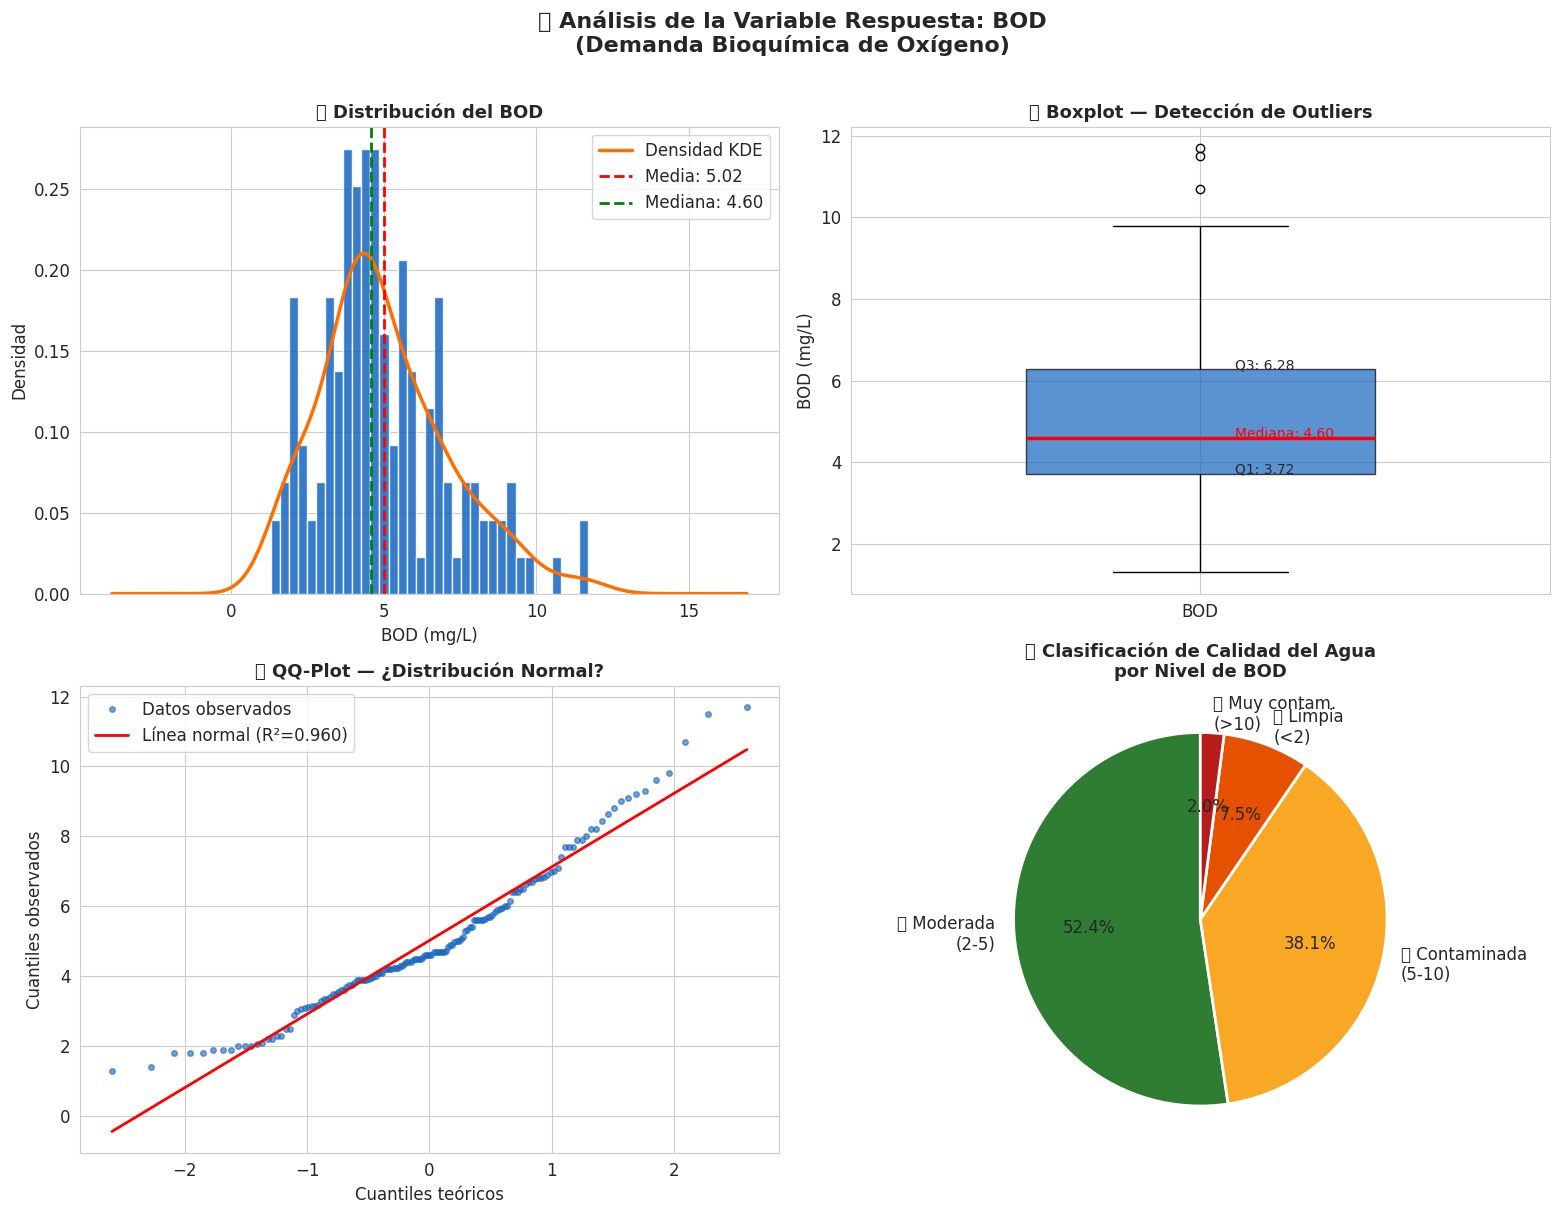

✅ Gráfica guardada: 'analisis_variable_respuesta_BOD.png'


In [9]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 5: Análisis de la Variable Respuesta — BOD
# ============================================================

var_resp = 'demanda_bioquimica_oxigeno'
datos_bod = df_train[var_resp].dropna()

# ── Estadísticas descriptivas ─────────────────────────────────
print("=" * 60)
print("  🎯 ESTADÍSTICAS — VARIABLE RESPUESTA: BOD")
print("=" * 60)

stats_bod = pd.DataFrame({
    'Estadístico': [
        '📊 Total registros',
        '✅ Valores completos',
        '❌ Valores nulos',
        '📉 Valor mínimo',
        '📈 Valor máximo',
        '📐 Media (promedio)',
        '📍 Mediana (Q2)',
        '📏 Desv. Estándar',
        '🔄 Asimetría (Skewness)',
        '📊 Curtosis (Kurtosis)',
        '🔲 Q1 (percentil 25)',
        '🔲 Q3 (percentil 75)',
        '📐 Rango Intercuartílico (IQR)'
    ],
    'Valor': [
        len(df_train),
        datos_bod.count(),
        df_train[var_resp].isnull().sum(),
        round(datos_bod.min(), 4),
        round(datos_bod.max(), 4),
        round(datos_bod.mean(), 4),
        round(datos_bod.median(), 4),
        round(datos_bod.std(), 4),
        round(datos_bod.skew(), 4),
        round(datos_bod.kurtosis(), 4),
        round(datos_bod.quantile(0.25), 4),
        round(datos_bod.quantile(0.75), 4),
        round(datos_bod.quantile(0.75) - datos_bod.quantile(0.25), 4)
    ],
    'Interpretación': [
        'Filas totales en el dataset',
        'Registros sin valores faltantes en BOD',
        'Registros con BOD desconocido',
        'BOD más bajo registrado en el río',
        'BOD más alto registrado en el río',
        'BOD promedio de todos los ríos',
        'El 50% de los ríos tienen este BOD o menos',
        'Variabilidad típica alrededor de la media',
        'Si >0: más valores altos; Si <0: más valores bajos',
        '>3: colas pesadas; <3: colas ligeras',
        'El 25% de ríos tienen BOD menor a este valor',
        'El 75% de ríos tienen BOD menor a este valor',
        'Rango del 50% central de los datos'
    ]
})

display(stats_bod)

# ── Visualización completa ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🎯 Análisis de la Variable Respuesta: BOD\n(Demanda Bioquímica de Oxígeno)',
             fontsize=16, fontweight='bold', y=1.01)

# 1. Histograma con curva KDE
axes[0,0].hist(datos_bod, bins=35, color='#1565C0',
               edgecolor='white', alpha=0.85, density=True)
datos_bod.plot.kde(ax=axes[0,0], color='#FF6F00',
                   linewidth=2.5, label='Densidad KDE')
axes[0,0].axvline(datos_bod.mean(), color='red',
                   linestyle='--', linewidth=2,
                   label=f'Media: {datos_bod.mean():.2f}')
axes[0,0].axvline(datos_bod.median(), color='green',
                   linestyle='--', linewidth=2,
                   label=f'Mediana: {datos_bod.median():.2f}')
axes[0,0].set_title('📊 Distribución del BOD', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('BOD (mg/L)')
axes[0,0].set_ylabel('Densidad')
axes[0,0].legend()

# 2. Boxplot
bp = axes[0,1].boxplot(datos_bod, patch_artist=True, vert=True,
                        widths=0.5)
bp['boxes'][0].set_facecolor('#1565C0')
bp['boxes'][0].set_alpha(0.7)
bp['medians'][0].set_color('red')
bp['medians'][0].set_linewidth(2.5)
axes[0,1].set_title('📦 Boxplot — Detección de Outliers',
                      fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('BOD (mg/L)')
axes[0,1].set_xticklabels(['BOD'])

# Añadir anotaciones en el boxplot
q1  = datos_bod.quantile(0.25)
q3  = datos_bod.quantile(0.75)
med = datos_bod.median()
axes[0,1].annotate(f'Mediana: {med:.2f}', xy=(1.05, med),
                    fontsize=10, color='red')
axes[0,1].annotate(f'Q3: {q3:.2f}', xy=(1.05, q3), fontsize=10)
axes[0,1].annotate(f'Q1: {q1:.2f}', xy=(1.05, q1), fontsize=10)

# 3. QQ-Plot (normalidad)
from scipy import stats as scipy_stats
(osm, osr), (slope, intercept, r) = scipy_stats.probplot(datos_bod,
                                                            dist="norm")
axes[1,0].plot(osm, osr, 'o', color='#1565C0', alpha=0.6,
               markersize=4, label='Datos observados')
axes[1,0].plot(osm, slope*np.array(osm)+intercept, 'r-',
               linewidth=2, label=f'Línea normal (R²={r**2:.3f})')
axes[1,0].set_title('📈 QQ-Plot — ¿Distribución Normal?',
                     fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Cuantiles teóricos')
axes[1,0].set_ylabel('Cuantiles observados')
axes[1,0].legend()

# 4. Clasificación de calidad
bins_cal  = [0, 2, 5, 10, float('inf')]
labels_cal = ['🟢 Limpia\n(<2)', '🟡 Moderada\n(2-5)',
               '🟠 Contaminada\n(5-10)', '🔴 Muy contam.\n(>10)']
categorias = pd.cut(datos_bod, bins=bins_cal, labels=labels_cal)
conteo = categorias.value_counts()

colores_cal = ['#2E7D32', '#F9A825', '#E65100', '#B71C1C']
axes[1,1].pie(conteo.values,
               labels=conteo.index,
               autopct='%1.1f%%',
               colors=colores_cal,
               startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1,1].set_title('🌊 Clasificación de Calidad del Agua\npor Nivel de BOD',
                     fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('analisis_variable_respuesta_BOD.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada: 'analisis_variable_respuesta_BOD.png'")

## 🔍 Paso 6: Análisis de Valores Nulos (NA / Missing Values)

### ¿Qué son los valores nulos?

Los valores nulos (también llamados **NA, NaN o Missing Values**)
son **datos faltantes** en el dataset — casillas vacías en la tabla.

En datasets de calidad de agua, los nulos ocurren porque:
- 🔬 El sensor falló durante la medición
- 📅 No se tomó muestra ese día
- 🧪 La muestra se perdió o contaminó en el laboratorio
- 📝 Error humano al registrar los datos

### ¿Por qué es importante analizarlos?

Los modelos de Machine Learning **NO pueden trabajar con datos faltantes**.
Si intentamos entrenar un modelo con nulos, obtendremos errores.
Por eso debemos:

1. **Identificar** cuántos y cuáles variables tienen nulos
2. **Visualizar** el patrón de los nulos
3. **Decidir** la mejor estrategia para tratarlos

### Estrategias para tratar valores nulos:

| Estrategia | Cuándo usarla | Ventaja | Desventaja |
|-----------|--------------|---------|------------|
| **Eliminar filas** | < 5% de nulos | Simple | Pérdida de datos |
| **Media/Mediana** | Nulos aleatorios | Rápido | Reduce varianza |
| **Moda** | Variables categóricas | Simple | No considera relaciones |
| **IterativeImputer** | Muchos nulos | Preciso | Más complejo |
| **KNNImputer** | Datos con patrones | Inteligente | Lento en grandes datos |

> 🌟 En este proyecto usaremos **IterativeImputer**
> (recomendado por el profesor), que es el método más sofisticado:
> usa las relaciones entre variables para estimar los valores faltantes.

In [10]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 6: Análisis Completo de Valores Nulos
# ============================================================

def analisis_nulos_completo(df, nombre_dataset, color='#1565C0'):
    """
    Función para analizar valores nulos de forma detallada y profesional.

    Parámetros:
    -----------
    df             : DataFrame a analizar
    nombre_dataset : Nombre para identificar el dataset (Train/Test)
    color          : Color para las visualizaciones
    """
    total_filas  = len(df)
    total_celdas = df.size

    # ── Tabla de análisis ─────────────────────────────────────
    tabla_nulos = pd.DataFrame({
        'Variable'          : df.columns,
        'Valores_Nulos'     : df.isnull().sum().values,
        'Valores_Completos' : df.notnull().sum().values,
        'Porcentaje_Nulos'  : (df.isnull().sum().values / total_filas * 100).round(2),
        'Tipo_Dato'         : df.dtypes.values
    }).sort_values('Porcentaje_Nulos', ascending=False)

    # Clasificación del nivel de nulos
    tabla_nulos['Nivel_Riesgo'] = tabla_nulos['Porcentaje_Nulos'].apply(
        lambda x:
        '🔴 CRÍTICO  (>50%)'   if x > 50 else
        '🟠 ALTO     (30-50%)' if x > 30 else
        '🟡 MODERADO (10-30%)' if x > 10 else
        '🟢 LEVE     (<10%)'   if x > 0  else
        '✅ COMPLETO (0%)'
    )

    # ── Resumen numérico ──────────────────────────────────────
    print("=" * 65)
    print(f"  🔍 ANÁLISIS DE NULOS — {nombre_dataset.upper()}")
    print("=" * 65)
    print(f"\n  📌 Total de filas           : {total_filas:,}")
    print(f"  📌 Total de celdas          : {total_celdas:,}")
    print(f"  📌 Total de valores nulos   : {df.isnull().sum().sum():,}")
    print(f"  📌 Variables con nulos      : {(df.isnull().sum() > 0).sum()}")
    print(f"  📌 Variables sin nulos      : {(df.isnull().sum() == 0).sum()}")
    print(f"  📌 % datos faltantes global : {df.isnull().sum().sum()/total_celdas*100:.2f}%")
    print("\n")
    display(tabla_nulos.reset_index(drop=True))

    return tabla_nulos

# ── Ejecutar análisis ─────────────────────────────────────────
print("\n")
nulos_train = analisis_nulos_completo(df_train, "TRAIN", '#1565C0')
print("\n")
nulos_test  = analisis_nulos_completo(df_test,  "TEST",  '#B71C1C')

print("\n✅ Análisis de nulos completado")



  🔍 ANÁLISIS DE NULOS — TRAIN

  📌 Total de filas           : 147
  📌 Total de celdas          : 1,323
  📌 Total de valores nulos   : 569
  📌 Variables con nulos      : 7
  📌 Variables sin nulos      : 2
  📌 % datos faltantes global : 43.01%




,Variable,Valores_Nulos,Valores_Completos,Porcentaje_Nulos,Tipo_Dato,Nivel_Riesgo
0,temperatura_agua,116,31,78.91,float64,🔴 CRÍTICO (>50%)
1,nivel_ph,115,32,78.23,float64,🔴 CRÍTICO (>50%)
2,nitrogeno_amonio,114,33,77.55,float64,🔴 CRÍTICO (>50%)
3,fosfato,110,37,74.83,float64,🔴 CRÍTICO (>50%)
4,nitrato,110,37,74.83,float64,🔴 CRÍTICO (>50%)
5,demanda_quimica_oxigeno,2,145,1.36,float64,🟢 LEVE (<10%)
6,oxigeno_disuelto,2,145,1.36,float64,🟢 LEVE (<10%)
7,Id,0,147,0.00,int64,✅ COMPLETO (0%)
8,demanda_bioquimica_oxigeno,0,147,0.00,float64,✅ COMPLETO (0%)




  🔍 ANÁLISIS DE NULOS — TEST

  📌 Total de filas           : 63
  📌 Total de celdas          : 504
  📌 Total de valores nulos   : 241
  📌 Variables con nulos      : 5
  📌 Variables sin nulos      : 3
  📌 % datos faltantes global : 47.82%




,Variable,Valores_Nulos,Valores_Completos,Porcentaje_Nulos,Tipo_Dato,Nivel_Riesgo
0,nitrato,49,14,77.78,float64,🔴 CRÍTICO (>50%)
1,fosfato,49,14,77.78,float64,🔴 CRÍTICO (>50%)
2,nivel_ph,48,15,76.19,float64,🔴 CRÍTICO (>50%)
3,temperatura_agua,48,15,76.19,float64,🔴 CRÍTICO (>50%)
4,nitrogeno_amonio,47,16,74.60,float64,🔴 CRÍTICO (>50%)
5,demanda_quimica_oxigeno,0,63,0.00,float64,✅ COMPLETO (0%)
6,Id,0,63,0.00,int64,✅ COMPLETO (0%)
7,oxigeno_disuelto,0,63,0.00,float64,✅ COMPLETO (0%)



✅ Análisis de nulos completado


## 📊 Paso 7: Visualización de Valores Nulos

### ¿Por qué visualizar los nulos?

Los números nos dicen **cuántos** nulos hay,
pero las visualizaciones nos dicen **dónde están**
y si tienen algún **patrón**.

### ¿Qué gráficas usamos?

| Gráfica | ¿Qué muestra? | ¿Qué buscamos? |
|---------|--------------|----------------|
| **Matriz de nulos** | Mapa visual de cada celda | Patrones de datos faltantes |
| **Barplot de completitud** | % de datos completos | Qué variables tienen más nulos |
| **Heatmap de correlación** | Relación entre nulos | Si una variable falta cuando otra también falta |
| **Dendrograma** | Agrupación de nulos similares | Variables con comportamiento similar de nulos |

### Interpretación del Heatmap de correlación de nulos:

- **Valor cercano a +1** → Cuando falta una variable,
  también falta la otra (nulos juntos)
- **Valor cercano a -1** → Cuando falta una, la otra está presente
- **Valor cercano a 0** → Los nulos son independientes entre sí

> 💡 Si los nulos están correlacionados, probablemente
> tienen una causa común (ej: el mismo sensor fallando).
> Esto es importante para elegir la estrategia de imputación.

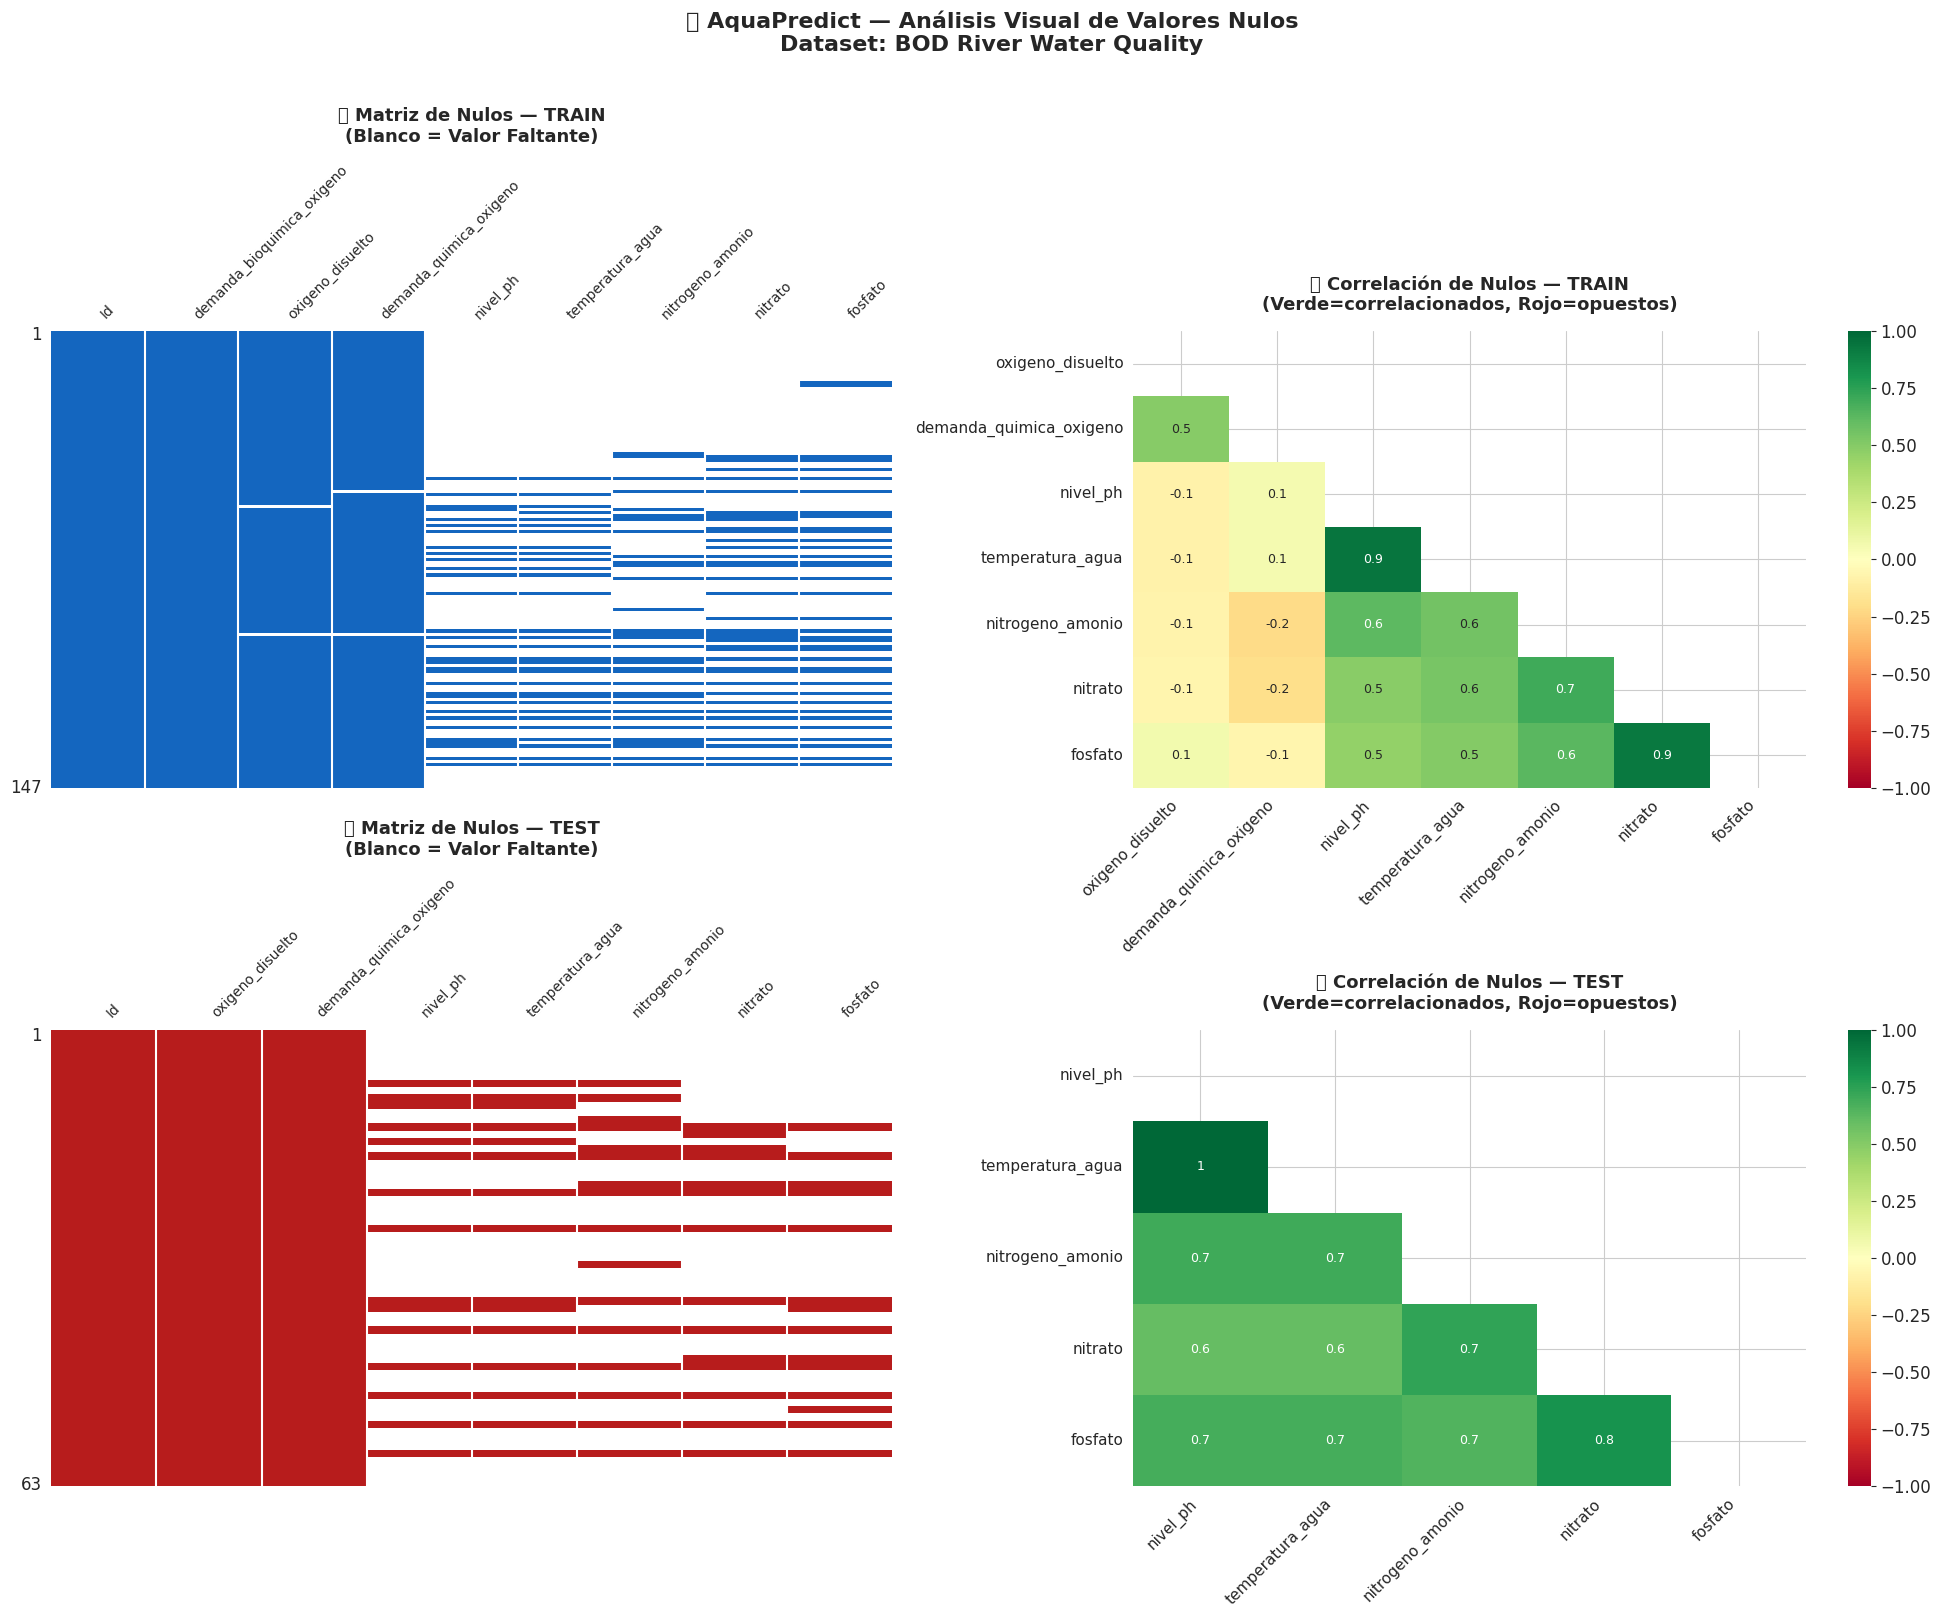

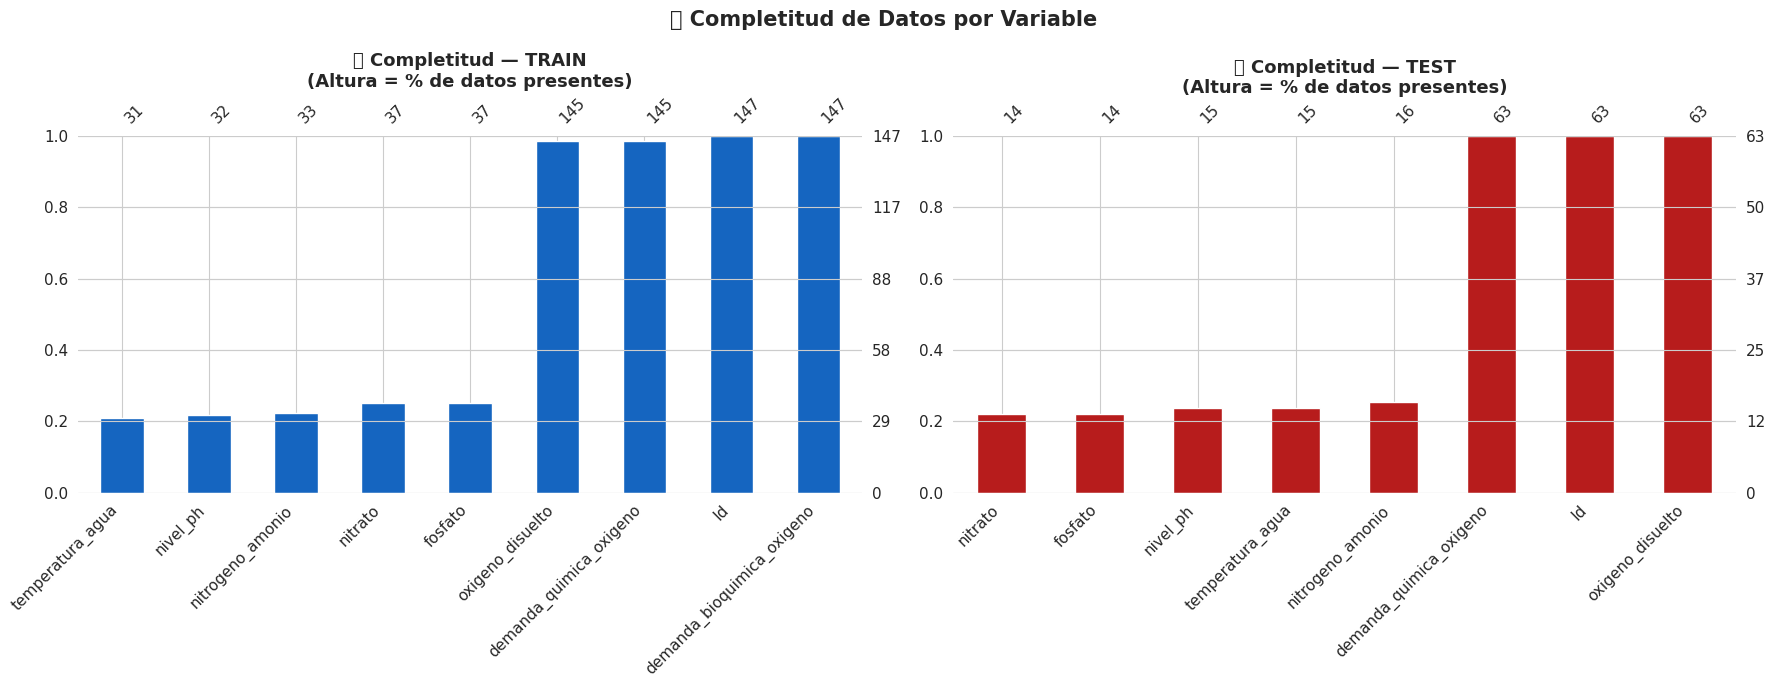

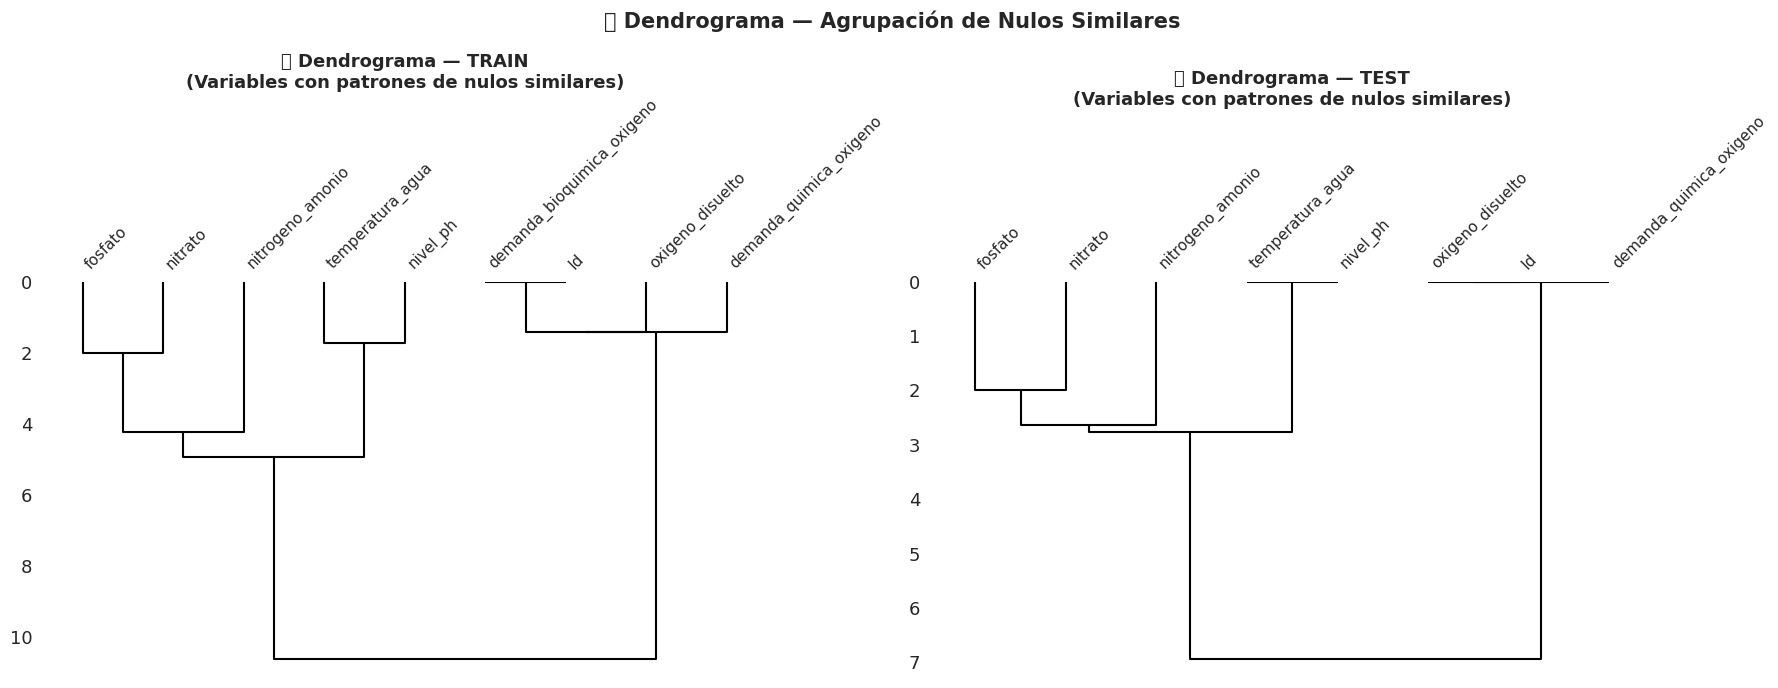

✅ Todas las visualizaciones guardadas correctamente


In [11]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 7: Visualización de Valores Nulos con Missingno
# ============================================================

# ── Figura 1: Comparativa Train vs Test ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('📊 AquaPredict — Análisis Visual de Valores Nulos\nDataset: BOD River Water Quality',
             fontsize=16, fontweight='bold', y=1.01)

# Matriz TRAIN
msno.matrix(df_train, ax=axes[0,0],
            color=(0.08, 0.40, 0.75),
            fontsize=10, sparkline=True)
axes[0,0].set_title('🔍 Matriz de Nulos — TRAIN\n(Blanco = Valor Faltante)',
                     fontsize=13, fontweight='bold', pad=15)

# Heatmap TRAIN
msno.heatmap(df_train, ax=axes[0,1],
             cmap='RdYlGn', fontsize=11)
axes[0,1].set_title('🌡️ Correlación de Nulos — TRAIN\n(Verde=correlacionados, Rojo=opuestos)',
                     fontsize=13, fontweight='bold', pad=15)

# Matriz TEST
msno.matrix(df_test, ax=axes[1,0],
            color=(0.72, 0.11, 0.11),
            fontsize=10, sparkline=True)
axes[1,0].set_title('🔍 Matriz de Nulos — TEST\n(Blanco = Valor Faltante)',
                     fontsize=13, fontweight='bold', pad=15)

# Heatmap TEST
msno.heatmap(df_test, ax=axes[1,1],
             cmap='RdYlGn', fontsize=11)
axes[1,1].set_title('🌡️ Correlación de Nulos — TEST\n(Verde=correlacionados, Rojo=opuestos)',
                     fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('visualizacion_nulos_completa.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figura 2: Barplot de completitud ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('📊 Completitud de Datos por Variable',
             fontsize=15, fontweight='bold')

msno.bar(df_train, ax=axes[0],
         color='#1565C0', fontsize=11,
         sort='ascending')
axes[0].set_title('✅ Completitud — TRAIN\n(Altura = % de datos presentes)',
                   fontsize=13, fontweight='bold')

msno.bar(df_test, ax=axes[1],
         color='#B71C1C', fontsize=11,
         sort='ascending')
axes[1].set_title('✅ Completitud — TEST\n(Altura = % de datos presentes)',
                   fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('completitud_datos.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figura 3: Dendrograma ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('🌳 Dendrograma — Agrupación de Nulos Similares',
             fontsize=15, fontweight='bold')

msno.dendrogram(df_train, ax=axes[0], fontsize=11)
axes[0].set_title('🌳 Dendrograma — TRAIN\n(Variables con patrones de nulos similares)',
                   fontsize=13, fontweight='bold')

msno.dendrogram(df_test, ax=axes[1], fontsize=11)
axes[1].set_title('🌳 Dendrograma — TEST\n(Variables con patrones de nulos similares)',
                   fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('dendrograma_nulos.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Todas las visualizaciones guardadas correctamente")

## 📊 Paso 8: Estadísticas Descriptivas Completas

### ¿Por qué analizar las estadísticas descriptivas?

Las estadísticas descriptivas nos dan un **resumen matemático**
de cada variable. Son la base de todo análisis de datos y nos
permiten responder preguntas como:

- ¿Cuál es el valor típico de cada parámetro del agua?
- ¿Qué tan dispersos están los datos?
- ¿Hay variables con valores extremos inusuales?
- ¿Las variables siguen una distribución normal?

### ¿Qué significa cada estadístico?

| Estadístico | Símbolo | Significado |
|------------|---------|-------------|
| **count** | n | Número de valores no nulos |
| **mean** | x̄ | Promedio aritmético |
| **std** | σ | Desviación estándar |
| **min** | | Valor mínimo |
| **25%** | Q1 | Primer cuartil |
| **50%** | Q2 | Mediana |
| **75%** | Q3 | Tercer cuartil |
| **max** | | Valor máximo |
| **CV%** | | Coeficiente de variación |
| **skewness** | γ₁ | Asimetría |

### ¿Qué es el Coeficiente de Variación (CV)?

El CV nos dice qué tan variable es una medición **en relación a su promedio**:
- **CV < 15%** → Datos poco variables (consistentes)
- **CV 15-30%** → Variabilidad moderada
- **CV > 30%** → Datos muy variables (alta dispersión)

  📊 ESTADÍSTICAS DESCRIPTIVAS — DATASET TRAIN


,count,mean,std,min,25%,50%,75%,max,CV_%,IQR,Rango,Asimetría,Curtosis,Nulos
Id,147.0,101.4014,64.8366,0.00,41.500,102.00,158.500,214.00,63.94,117.000,214.00,0.1103,-1.2861,0
demanda_bioquimica_oxigeno,147.0,5.0216,2.1225,1.30,3.720,4.60,6.275,11.70,42.27,2.555,10.40,0.7383,0.4827,0
oxigeno_disuelto,145.0,4.9726,2.0441,0.90,3.500,4.80,6.450,10.90,41.11,2.950,10.00,0.4534,0.0091,2
demanda_quimica_oxigeno,145.0,4.9066,2.0014,1.04,3.400,4.83,6.200,11.00,40.79,2.800,9.96,0.3612,-0.0385,2
nivel_ph,32.0,4.6650,2.0574,2.04,3.325,4.15,5.970,10.66,44.10,2.645,8.62,0.8857,0.7688,115
temperatura_agua,31.0,5.8716,2.5552,2.48,4.445,5.50,6.400,14.79,43.52,1.955,12.31,1.6056,3.8783,116
nitrogeno_amonio,33.0,8.6788,5.2991,2.88,5.840,7.30,8.420,27.12,61.06,2.580,24.24,2.6616,7.3543,114
nitrato,37.0,3.8838,1.6155,1.00,2.900,3.40,4.800,8.54,41.59,1.900,7.54,1.0258,0.9743,110
fosfato,37.0,3.9576,1.9170,1.60,2.900,3.50,4.400,10.37,48.44,1.500,8.77,1.6171,2.7598,110


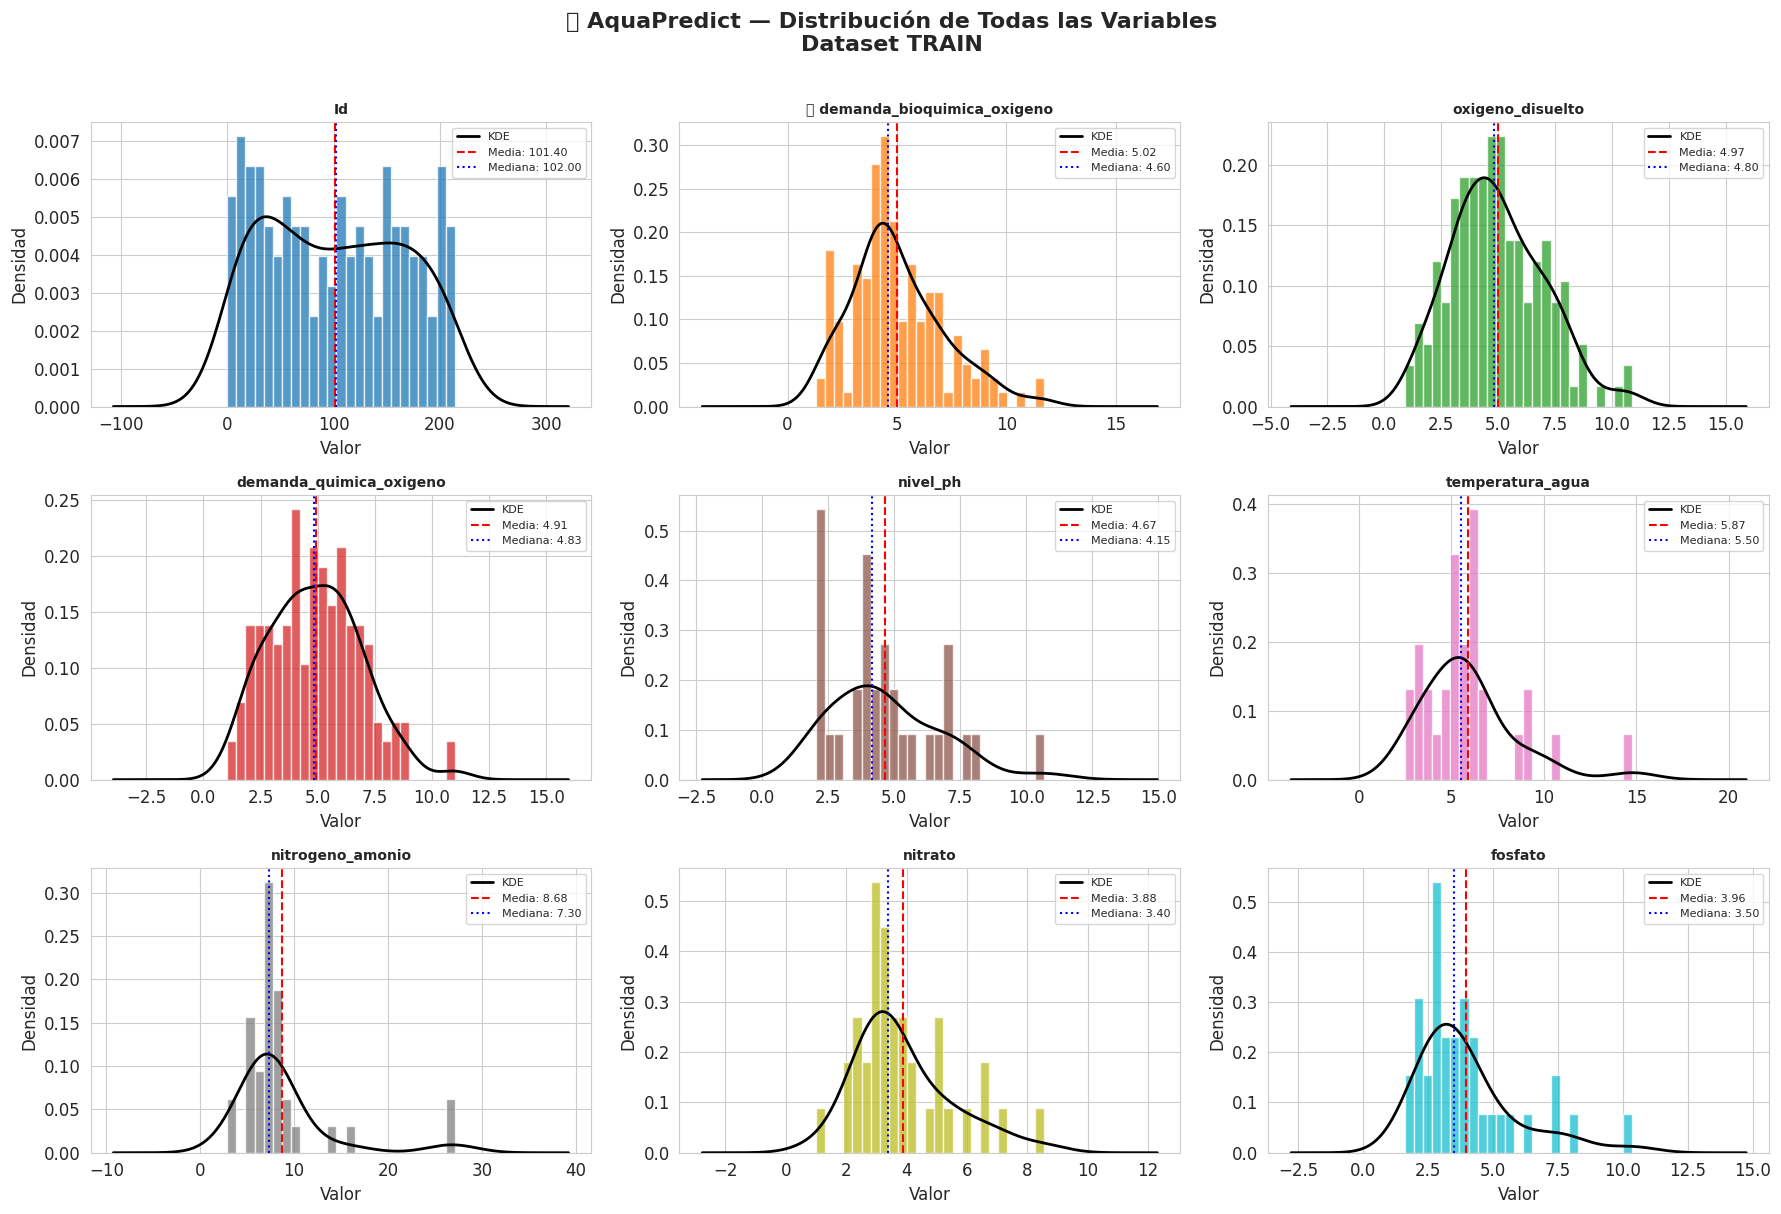

✅ Estadísticas guardadas: 'estadisticas_descriptivas_train.csv'


In [12]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 8: Estadísticas Descriptivas Completas
# ============================================================

print("=" * 65)
print("  📊 ESTADÍSTICAS DESCRIPTIVAS — DATASET TRAIN")
print("=" * 65)

# ── Estadísticas ampliadas ────────────────────────────────────
stats = df_train.describe().T

# Añadimos estadísticos adicionales
stats['CV_%']      = (stats['std'] / stats['mean'] * 100).round(2)
stats['IQR']       = (stats['75%'] - stats['25%']).round(4)
stats['Rango']     = (stats['max'] - stats['min']).round(4)
stats['Asimetría'] = df_train.skew().round(4)
stats['Curtosis']  = df_train.kurtosis().round(4)
stats['Nulos']     = df_train.isnull().sum()

# Redondear y mostrar
stats = stats.round(4)
display(stats)

# ── Visualización: Distribución de todas las variables ────────
variables_numericas = df_train.select_dtypes(include=[np.number]).columns.tolist()
n_vars = len(variables_numericas)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(18, n_rows * 4))
fig.suptitle('📊 AquaPredict — Distribución de Todas las Variables\nDataset TRAIN',
             fontsize=16, fontweight='bold', y=1.01)

axes_flat = axes.flatten()

colores = plt.cm.tab10(np.linspace(0, 1, n_vars))

for i, (var, color) in enumerate(zip(variables_numericas, colores)):
    ax = axes_flat[i]
    datos_var = df_train[var].dropna()

    # Histograma + KDE
    ax.hist(datos_var, bins=25, color=color,
            edgecolor='white', alpha=0.75, density=True)
    try:
        datos_var.plot.kde(ax=ax, color='black',
                           linewidth=2, label='KDE')
    except Exception:
        pass

    # Líneas de media y mediana
    ax.axvline(datos_var.mean(), color='red',
               linestyle='--', linewidth=1.5,
               label=f'Media: {datos_var.mean():.2f}')
    ax.axvline(datos_var.median(), color='blue',
               linestyle=':', linewidth=1.5,
               label=f'Mediana: {datos_var.median():.2f}')

    # Marcar variable respuesta
    titulo = f'🎯 {var}' if var == 'demanda_bioquimica_oxigeno' else var
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

# Ocultar ejes vacíos
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('distribucion_todas_variables.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Guardar estadísticas
stats.to_csv('estadisticas_descriptivas_train.csv')
print("✅ Estadísticas guardadas: 'estadisticas_descriptivas_train.csv'")

## 🌡️ Paso 9: Análisis de Correlaciones

### ¿Qué es la correlación?

La correlación mide **qué tan relacionadas están dos variables**.
Si conocemos el valor de una, ¿podemos intuir el valor de la otra?

### Coeficiente de Pearson (r):

| Valor de r | Interpretación |
|-----------|----------------|
| **1.0** | Correlación positiva perfecta |
| **0.7 a 0.9** | Correlación positiva fuerte |
| **0.4 a 0.7** | Correlación positiva moderada |
| **0.1 a 0.4** | Correlación positiva débil |
| **0** | Sin correlación |
| **-0.1 a -0.4** | Correlación negativa débil |
| **-0.4 a -0.7** | Correlación negativa moderada |
| **-0.7 a -1.0** | Correlación negativa fuerte |

### ¿Por qué importa la correlación con el BOD?

Las variables **más correlacionadas con el BOD** serán
las más importantes para el modelo predictivo.

> ⚠️ Si dos variables predictoras están muy correlacionadas
> entre sí (multicolinealidad), puede afectar negativamente al modelo.
> Esto también lo detectamos con la matriz de correlaciones.

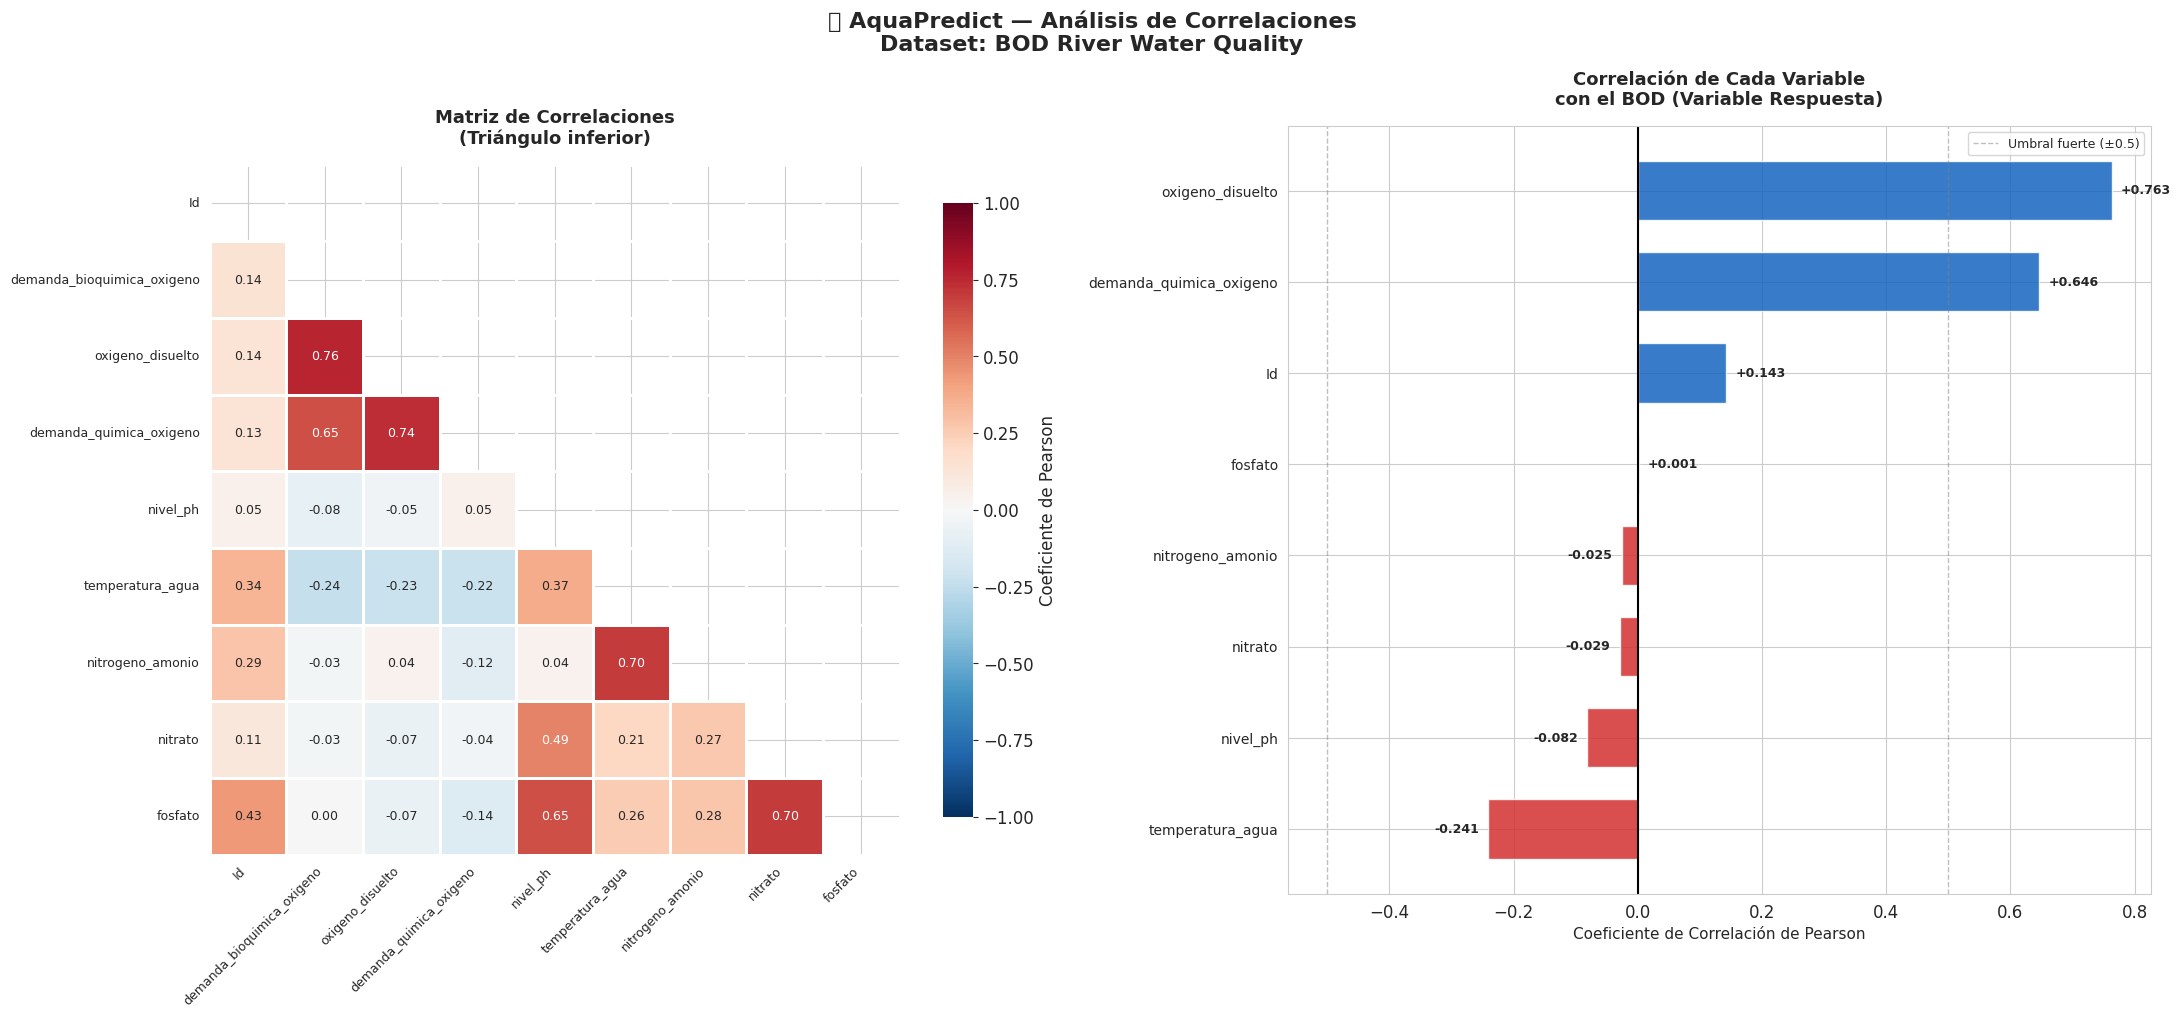


  📊 RANKING DE CORRELACIÓN CON BOD


,Variable,Correlación,Dirección,Fuerza
0,oxigeno_disuelto,0.7628,📈 Positiva,🔴 Fuerte
1,demanda_quimica_oxigeno,0.6458,📈 Positiva,🔴 Fuerte
2,temperatura_agua,0.2407,📉 Negativa,🟢 Débil
3,Id,0.1426,📈 Positiva,🟢 Débil
4,nivel_ph,0.0819,📉 Negativa,🟢 Débil
5,nitrato,0.0292,📉 Negativa,🟢 Débil
6,nitrogeno_amonio,0.0255,📉 Negativa,🟢 Débil
7,fosfato,0.0013,📈 Positiva,🟢 Débil



✅ Análisis de correlaciones completado


In [13]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 9: Análisis de Correlaciones
# ============================================================

corr_matrix = df_train.corr()

fig = plt.figure(figsize=(22, 10))
fig.suptitle('🌡️ AquaPredict — Análisis de Correlaciones\nDataset: BOD River Water Quality',
             fontsize=16, fontweight='bold')

# ── Subplot 1: Heatmap completo ───────────────────────────────
ax1 = fig.add_subplot(1, 2, 1)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
hm = sns.heatmap(
    corr_matrix,
    ax=ax1,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.8,
    linecolor='white',
    annot_kws={'size': 9},
    cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'}
)
ax1.set_title('Matriz de Correlaciones\n(Triángulo inferior)',
               fontsize=13, fontweight='bold', pad=15)
ax1.set_xticklabels(ax1.get_xticklabels(),
                     rotation=45, ha='right', fontsize=9)
ax1.set_yticklabels(ax1.get_yticklabels(),
                     rotation=0, fontsize=9)

# ── Subplot 2: Correlación con BOD ───────────────────────────
ax2 = fig.add_subplot(1, 2, 2)
var_resp     = 'demanda_bioquimica_oxigeno'
corr_con_bod = (corr_matrix[var_resp]
                .drop(var_resp)
                .sort_values())

colores_barra = ['#D32F2F' if v < 0 else '#1565C0'
                  for v in corr_con_bod.values]

barras = ax2.barh(
    range(len(corr_con_bod)),
    corr_con_bod.values,
    color=colores_barra,
    edgecolor='white',
    height=0.65,
    alpha=0.85
)

ax2.set_yticks(range(len(corr_con_bod)))
ax2.set_yticklabels(corr_con_bod.index, fontsize=10)
ax2.axvline(x=0, color='black', linewidth=1.5)
ax2.axvline(x=0.5,  color='gray', linewidth=1,
             linestyle='--', alpha=0.5, label='Umbral fuerte (±0.5)')
ax2.axvline(x=-0.5, color='gray', linewidth=1,
             linestyle='--', alpha=0.5)
ax2.set_xlabel('Coeficiente de Correlación de Pearson', fontsize=11)
ax2.set_title(f'Correlación de Cada Variable\ncon el BOD (Variable Respuesta)',
               fontsize=13, fontweight='bold', pad=15)
ax2.legend(fontsize=9)

# Añadir valores en las barras
for i, (val, barra) in enumerate(zip(corr_con_bod.values, barras)):
    offset = 0.015 if val >= 0 else -0.015
    ha_val  = 'left'  if val >= 0 else 'right'
    ax2.text(val + offset, i,
              f'{val:+.3f}', va='center',
              ha=ha_val, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('analisis_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla de correlaciones con BOD ───────────────────────────
print("\n" + "=" * 55)
print("  📊 RANKING DE CORRELACIÓN CON BOD")
print("=" * 55)

tabla_corr = pd.DataFrame({
    'Variable'     : corr_con_bod.abs().sort_values(ascending=False).index,
    'Correlación'  : corr_con_bod.abs().sort_values(ascending=False).values.round(4),
    'Dirección'    : ['📈 Positiva' if corr_con_bod[v] > 0 else '📉 Negativa'
                       for v in corr_con_bod.abs().sort_values(ascending=False).index],
    'Fuerza'       : ['🔴 Fuerte'   if abs(v) > 0.5
                       else '🟡 Moderada' if abs(v) > 0.3
                       else '🟢 Débil'
                       for v in corr_con_bod.abs().sort_values(ascending=False).values]
})

display(tabla_corr.reset_index(drop=True))
print("\n✅ Análisis de correlaciones completado")

## 📋 Paso 10: Resumen del Análisis Exploratorio (EDA)

### ¿Qué aprendimos en este análisis?

Completamos el **Análisis Exploratorio de Datos (EDA)**
que es la primera etapa fundamental en todo proyecto
de Ciencia de Datos.

### ✅ Lo que hicimos:

| Paso | Actividad | Resultado |
|------|-----------|-----------|
| 1 | Carga de librerías | Ambiente configurado |
| 2 | Carga de datos | Train y Test importados |
| 3 | Exploración inicial | Estructura del dataset entendida |
| 4 | Renombrado de variables | Variables con nombres descriptivos |
| 5 | Análisis variable respuesta (BOD) | Distribución y estadísticas del BOD |
| 6 | Análisis de nulos | Cantidad y patrón de datos faltantes |
| 7 | Visualización de nulos | Mapa visual de datos faltantes |
| 8 | Estadísticas descriptivas | Resumen matemático de todas las variables |
| 9 | Análisis de correlaciones | Relaciones entre variables identificadas |

### 🚀 Próximos pasos:

1. **Imputación con IterativeImputer** → Rellenar valores nulos
2. **Detección y tratamiento de Outliers** → Manejar valores extremos
3. **Normalización/Estandarización** → Escalar las variables
4. **Feature Engineering** → Crear nuevas variables
5. **Modelado predictivo** → Entrenar modelos de ML

> 💡 El EDA es como el diagnóstico médico antes de la cirugía.
> Sin conocer bien los datos, cualquier modelo que construyamos
> tendrá resultados poco confiables.

In [59]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 10: Resumen Final del Análisis Exploratorio
# ============================================================

# ── Calcular métricas finales ─────────────────────────────────
var_resp = 'demanda_bioquimica_oxigeno'
nulos_train_total = df_train.isnull().sum().sum()
nulos_test_total  = df_test.isnull().sum().sum()
vars_con_nulos    = (df_train.isnull().sum() > 0).sum()
corr_top          = (df_train.corr()[var_resp]
                     .drop(var_resp)
                     .abs()
                     .idxmax())

# ── Imprimir resumen ──────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║         💧 AquaPredict — Grupo 5                                            ║
║         RESUMEN DEL ANÁLISIS EXPLORATORIO DE DATOS (EDA)                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  👥 EQUIPO                                                                  ║
║     → Karen Pertuz   | Gisselle Deford                                       ║
║     → Kelvin Jimenez | Javier Gomez                                          ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🎯 VARIABLE RESPUESTA                                                       ║
║     → BOD: Demanda Bioquímica de Oxígeno (mg/L)                              ║
║     → Tipo de problema: REGRESIÓN                                            ║""")
print(f"║     → Media del BOD : {df_train[var_resp].mean():.4f} mg/L" + " " * 30 + "              ║")
print(f"║     → Rango del BOD : {df_train[var_resp].min():.2f} - {df_train[var_resp].max():.2f} mg/L" + " " * 24 + "              ║")
print(f"""║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  📊 DATASET                                                                  ║""")
print(f"║     → Train: {df_train.shape[0]:,} filas × {df_train.shape[1]} columnas" + " " * 36 + "      ║")
print(f"║     → Test : {df_test.shape[0]:,} filas × {df_test.shape[1]} columnas" + " " * 37 + "      ║")
print(f"""║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  ⚠️  VALORES NULOS                                                          ║""")
print(f"║     → Train: {nulos_train_total:,} valores nulos" + " " * 43 + "    ║")
print(f"║     → Test : {nulos_test_total:,} valores nulos" + " " * 44 + "   ║")
print(f"║     → Variables afectadas: {vars_con_nulos}" + " " * 38 + "           ║")
print(f"║     → Estrategia: IterativeImputer (ML-based)" + " " * 19 + "             ║")
print(f"""║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🔗 CORRELACIONES                                                            ║""")
print(f"║     → Variable más correlacionada con BOD: {corr_top}" + " " * 10 + "        ║")
print(f"""║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🚀 PRÓXIMOS PASOS                                                           ║
║     1. Imputación con IterativeImputer                                       ║
║     2. Detección y tratamiento de Outliers                                   ║
║     3. Normalización de variables                                            ║
║     4. Entrenamiento de modelos predictivos                                  ║
║     5. Evaluación y selección del mejor modelo                               ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

print("✅ ¡Análisis Exploratorio completado exitosamente!")
print("🚀 Listo para la etapa de Imputación de Datos")


╔══════════════════════════════════════════════════════════════════════════════╗
║         💧 AquaPredict — Grupo 5                                            ║
║         RESUMEN DEL ANÁLISIS EXPLORATORIO DE DATOS (EDA)                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  👥 EQUIPO                                                                  ║
║     → Karen Pertuz   | Gisselle Deford                                       ║
║     → Kelvin Jimenez | Javier Gomez                                          ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🎯 VARIABLE RESPUESTA                                                       ║
║     → BOD: Demanda Bioquímica 

## 🔍 Paso 11: Análisis de Datos Faltantes (Null / NA)

### ¿Por qué es crítico este paso?

Antes de imputar o modelar, debemos entender la **naturaleza de los datos faltantes**.
Siguiendo la metodología de las imágenes de referencia, debemos responder:

1. **¿Cuántos datos faltan?** → Calcular el porcentaje global y por columna.
2. **¿Dónde están?** → Identificar si es aleatorio o sigue un patrón.
3. **¿Cuál es el umbral?** → Decidir si eliminamos columnas o imputamos.

### Estrategia de Umbral (Threshold)

Basado en la teoría estadística:
- **< 5% de nulos**: Se puede imputar con media/mediana o modelos avanzados.
- **> 5% de nulos**: La columna es sospechosa. Se evalúa si eliminarla o usar imputación iterativa.
- **> 30% de nulos**: Generalmente se elimina la columna (no aporta información).

### Herramientas de Visualización

Usaremos la librería `missingno` (como se vio en las imágenes) para crear:
- **Matriz de nulos**: Para ver patrones.
- **Gráfico de barras**: Para ver el volumen de faltantes.

  📊 CÁLCULO DE PORCENTAJE DE VALORES FALTANTES

📋 TABLA DE ANÁLISIS DE DATOS FALTANTES (TRAIN):
────────────────────────────────────────────────────────────


,Variable,Cantidad_Nulos,Porcentaje_%,Completitud_%,Umbral_Recomendado
temperatura_agua,temperatura_agua,116,78.91,21.09,❌ ELIMINAR
nivel_ph,nivel_ph,115,78.23,21.77,❌ ELIMINAR
nitrogeno_amonio,nitrogeno_amonio,114,77.55,22.45,❌ ELIMINAR
fosfato,fosfato,110,74.83,25.17,❌ ELIMINAR
nitrato,nitrato,110,74.83,25.17,❌ ELIMINAR
demanda_quimica_oxigeno,demanda_quimica_oxigeno,2,1.36,98.64,✅ IMPUTAR
oxigeno_disuelto,oxigeno_disuelto,2,1.36,98.64,✅ IMPUTAR
Id,Id,0,0.00,100.00,✅ IMPUTAR
demanda_bioquimica_oxigeno,demanda_bioquimica_oxigeno,0,0.00,100.00,✅ IMPUTAR



📈 UMBRAL DEFINIDO: 5.0%
✅ Columnas a imputar directamente: 4
⚠️ Columnas a revisar estrategia: 0


<Figure size 1400x600 with 0 Axes>

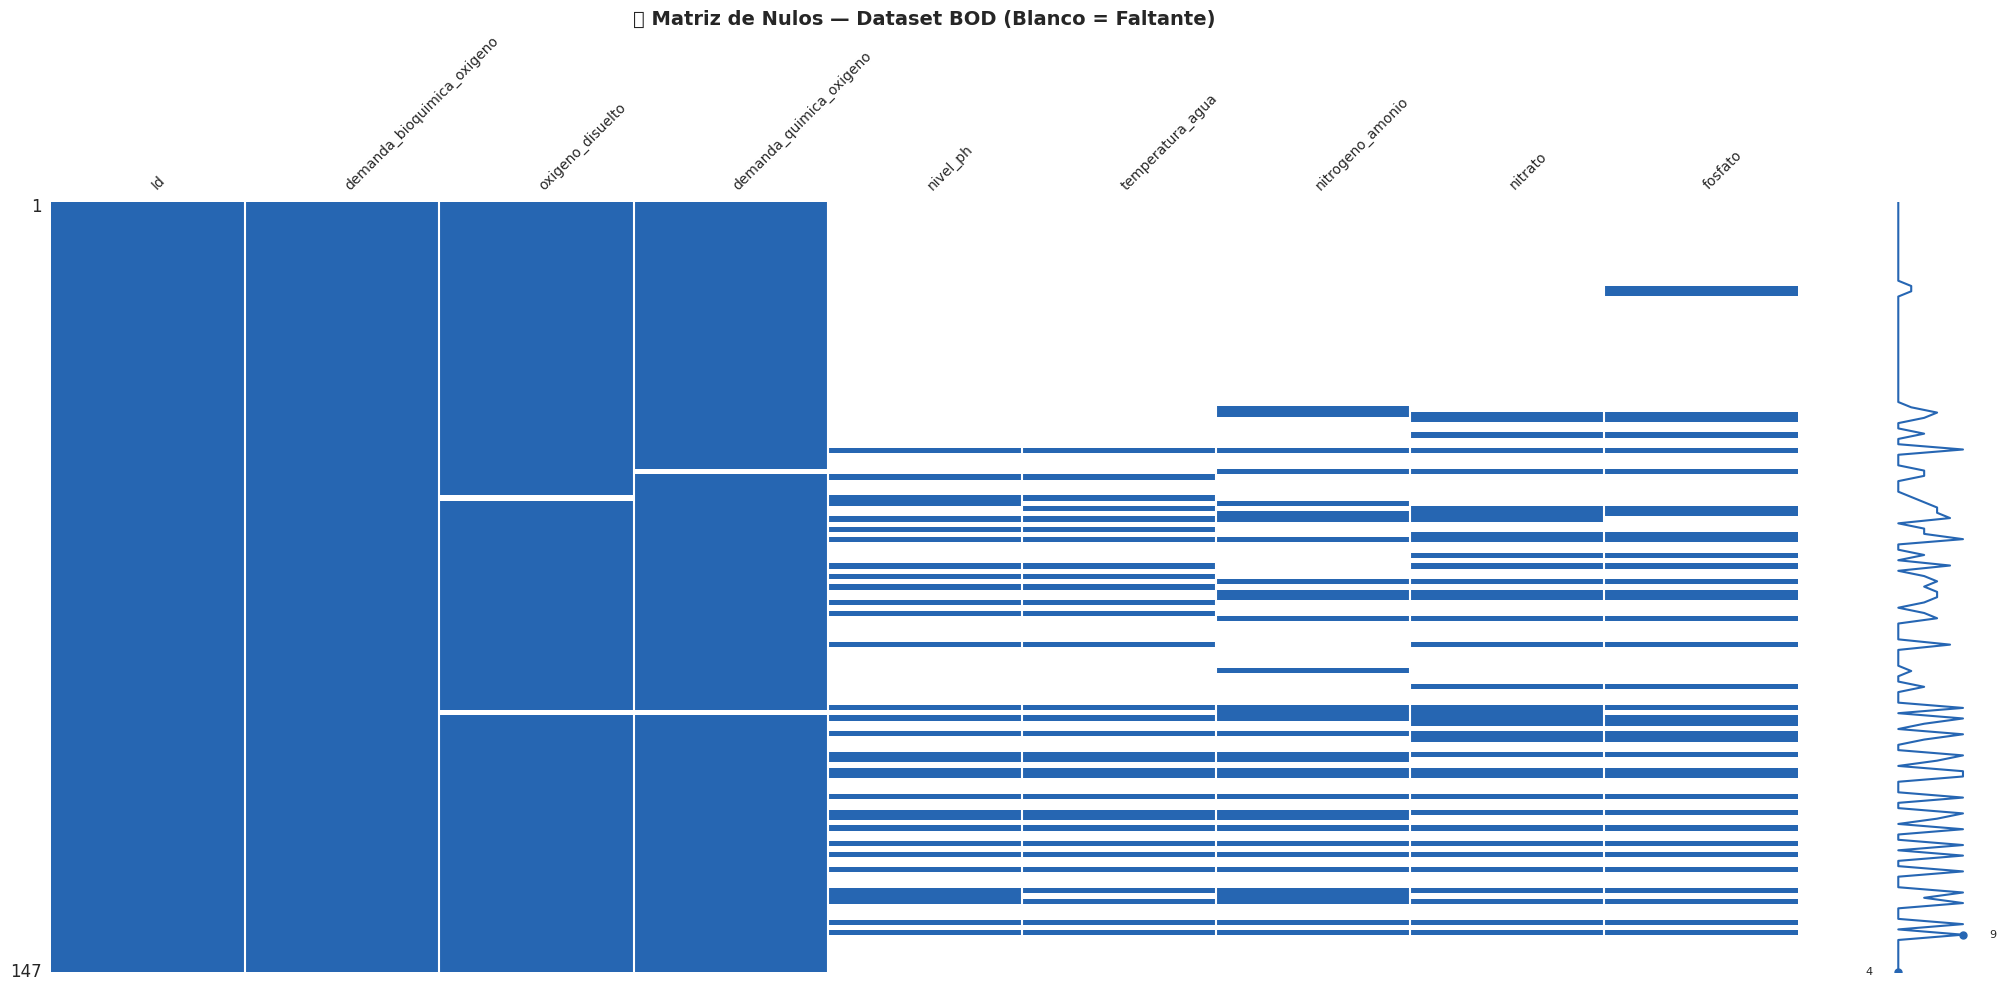

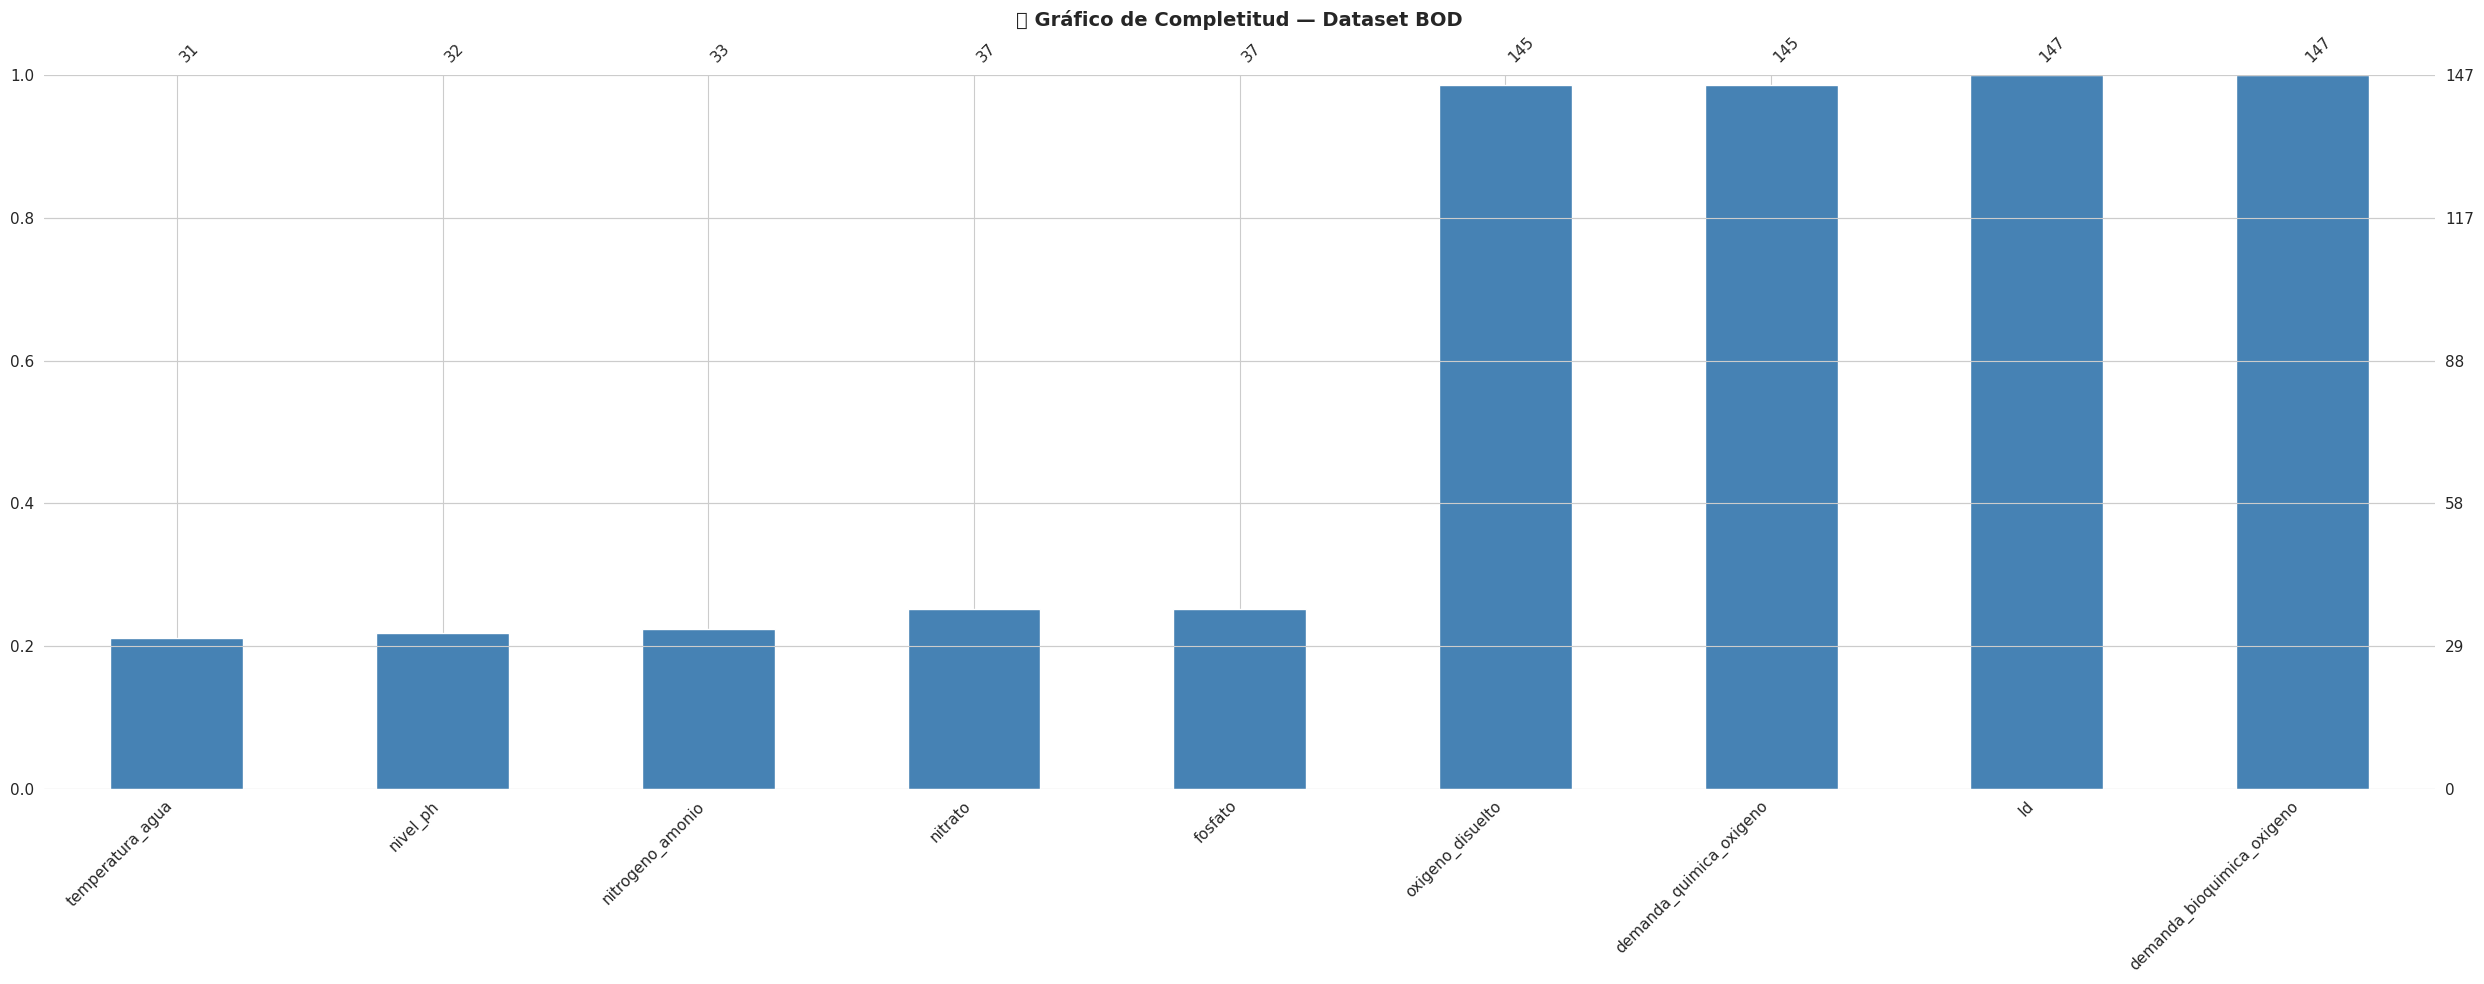

✅ Análisis de nulos completado. Gráficas guardadas.


In [60]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 11: Análisis Detallado de Datos Faltantes
# ============================================================

import missingno as msno

print("=" * 60)
print("  📊 CÁLCULO DE PORCENTAJE DE VALORES FALTANTES")
print("=" * 60)

# ── 1. Calcular porcentaje de nulos por columna ─────────────
nulos_por_col = df_train.isnull().sum()
total_filas = len(df_train)
porcentaje_nulos = (nulos_por_col / total_filas * 100).round(2)

# ── 2. Crear DataFrame de análisis ──────────────────────────
df_analisis_nulos = pd.DataFrame({
    'Variable'          : nulos_por_col.index,
    'Cantidad_Nulos'     : nulos_por_col.values,
    'Porcentaje_%'       : porcentaje_nulos.values,
    'Completitud_%'      : (100 - porcentaje_nulos).round(2),
    'Umbral_Recomendado' : ['✅ IMPUTAR' if p < 5.0
                            else '⚠️ REVISAR' if p < 20.0
                            else '❌ ELIMINAR'
                            for p in porcentaje_nulos.values]
})

# Ordenar por cantidad de nulos (mayor a menor)
df_analisis_nulos = df_analisis_nulos.sort_values('Cantidad_Nulos', ascending=False)

print("\n📋 TABLA DE ANÁLISIS DE DATOS FALTANTES (TRAIN):")
print("─" * 60)
display(df_analisis_nulos)

# ── 3. Definir Umbral y Estrategia ─────────────────────────
umbral_critico = 5.0 # Porcentaje
cols_a_imputar = df_analisis_nulos[df_analisis_nulos['Porcentaje_%'] < umbral_critico]['Variable'].tolist()
cols_a_revisar = df_analisis_nulos[(df_analisis_nulos['Porcentaje_%'] >= umbral_critico) &
                                   (df_analisis_nulos['Porcentaje_%'] < 20)]['Variable'].tolist()

print(f"\n📈 UMBRAL DEFINIDO: {umbral_critico}%")
print(f"✅ Columnas a imputar directamente: {len(cols_a_imputar)}")
print(f"⚠️ Columnas a revisar estrategia: {len(cols_a_revisar)}")

# ── 4. Visualización Matricial (Estilo Referencia) ───────
plt.figure(figsize=(14, 6))
msno.matrix(df_train, color=(0.15, 0.4, 0.7), fontsize=10, sparkline=True)
plt.title('🔍 Matriz de Nulos — Dataset BOD (Blanco = Faltante)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_nulos_bod.png', dpi=150)
plt.show()

# ── 5. Visualización de Barras (Estilo Referencia) ───────
plt.figure(figsize=(14, 6))
msno.bar(df_train, color='steelblue', fontsize=11, sort='ascending')
plt.title('📊 Gráfico de Completitud — Dataset BOD', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('barra_nulos_bod.png', dpi=150)
plt.show()

print("✅ Análisis de nulos completado. Gráficas guardadas.")

## 🌡️ Paso 12: Análisis de Correlaciones (Bivariado)

### ¿Qué es el Análisis Bivariado?

Mientras el análisis univariado mira una variable a la vez,
el **bivariado** estudia la relación entre **dos variables**.

### Tipos de Correlación

| Tipo | Descripción | Gráfica típica |
|------|-------------|----------------|
| **Positiva** | Si una sube, la otra sube | / |
| **Negativa** | Si una sube, la otra baja | \ |
| **Nula** | No hay relación | ☁️ (Nube de puntos) |

### Coeficiente de Pearson ($\rho$)

Es el número que mide la fuerza de la relación:
- **+1.0**: Correlación perfecta positiva.
- **0.0**: Sin correlación lineal.
- **-1.0**: Correlación perfecta negativa.

### ¿Por qué es importante para el BOD?

Necesitamos saber qué variables (pH, Temperatura, Oxígeno)
están **más correlacionadas con el BOD** para seleccionar
las mejores características (features) para nuestro modelo.

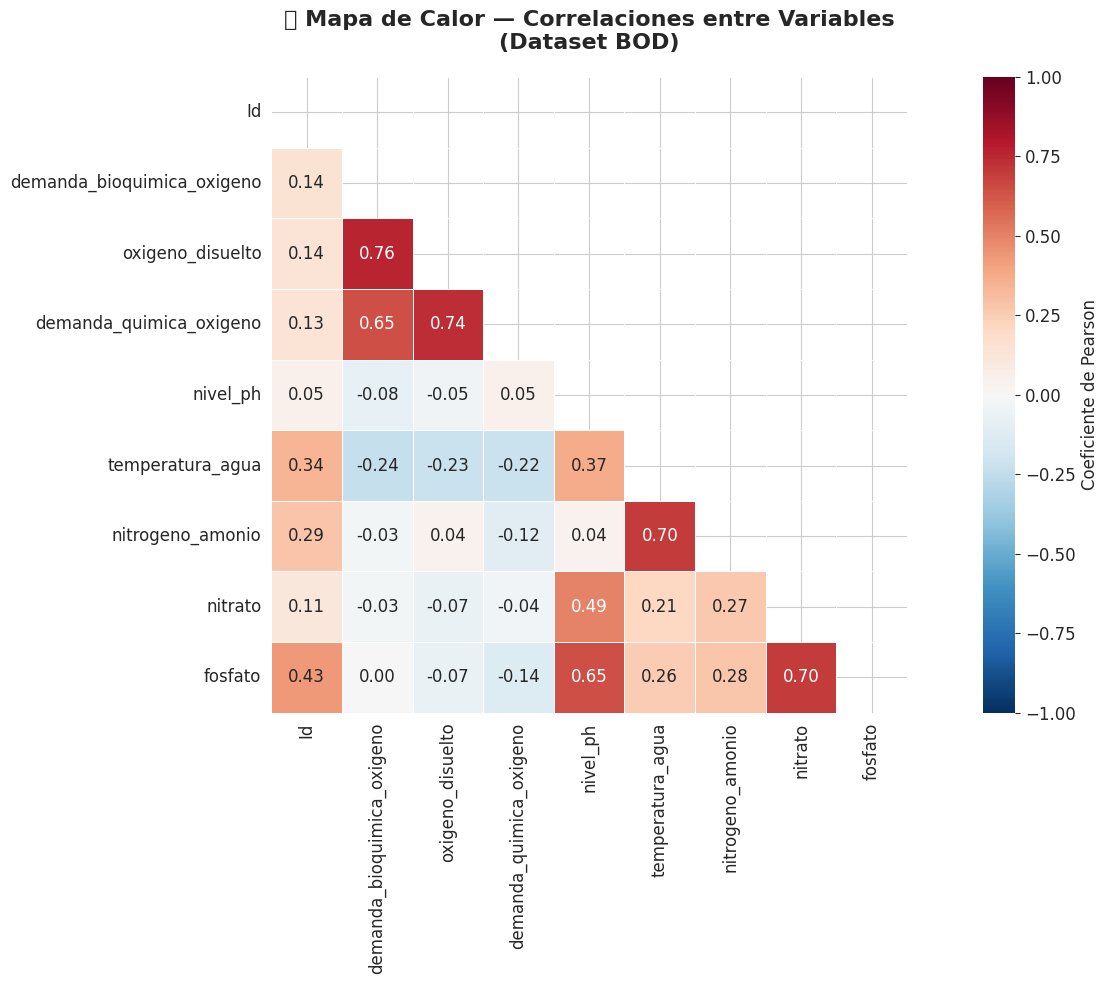

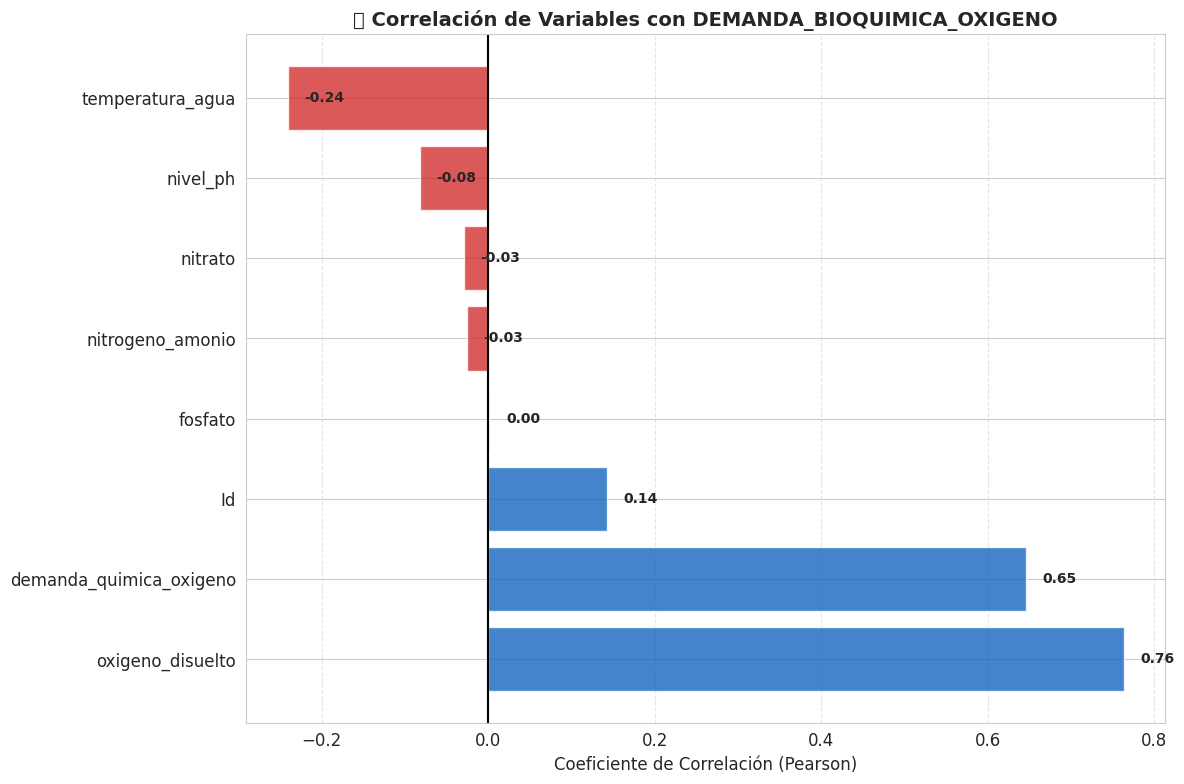

📊 TOP 5 VARIABLES MÁS CORRELACIONADAS CON EL BOD:
──────────────────────────────────────────────────
1. oxigeno_disuelto     → +0.763 (🔴 FUERTE)
2. demanda_quimica_oxigeno → +0.646 (🔴 FUERTE)
3. Id                   → +0.143 (🟡 MODERADA)
4. fosfato              → +0.001 (🟡 MODERADA)
5. nitrogeno_amonio     → -0.025 (🟡 MODERADA)


In [61]:
# ============================================================
# 💧 AquaPredict — Grupo 5
# Paso 12: Matriz de Correlaciones y Heatmap
# ============================================================

# ── 1. Calcular Matriz de Correlación ───────────────────────
# Solo usamos columnas numéricas para la correlación de Pearson
cols_numericas = df_train.select_dtypes(include=[np.number]).columns
corr_matrix = df_train[cols_numericas].corr()

# ── 2. Crear Heatmap (Estilo Referencia) ───────────────────
plt.figure(figsize=(16, 10))

# Máscara para ocultar la mitad superior (triángulo)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Gráfico
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,       # Muestra los números
    fmt='.2f',        # Formato de 2 decimales
    cmap='RdBu_r',    # Mapa de colores Rojo-Azul
    center=0,         # Centro en 0
    vmin=-1, vmax=1,  # Rango de -1 a 1
    square=True,      # Celdas cuadradas
    linewidths=0.5,   # Bordes blancos
    cbar_kws={'label': 'Coeficiente de Pearson'}
)

plt.title('🌡️ Mapa de Calor — Correlaciones entre Variables\n(Dataset BOD)',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('heatmap_correlaciones.png', dpi=150)
plt.show()

# ── 3. Ranking de Correlación con la Variable Respuesta ──
var_respuesta = 'demanda_bioquimica_oxigeno'
correlacion_con_respuesta = corr_matrix[var_respuesta].drop(var_respuesta).sort_values(ascending=False)

# ── 4. Gráfico de Barras Horizontales ───────────────────────
plt.figure(figsize=(12, 8))

# Colores: Rojo si es negativa, Azul si es positiva
colores = ['#D32F2F' if x < 0 else '#1565C0' for x in correlacion_con_respuesta.values]

bars = plt.barh(
    correlacion_con_respuesta.index,
    correlacion_con_respuesta.values,
    color=colores,
    alpha=0.8
)

plt.axvline(x=0, color='black', linewidth=1.5) # Línea vertical en 0
plt.title(f'🔗 Correlación de Variables con {var_respuesta.upper()}',
          fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente de Correlación (Pearson)')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Añadir valores en las barras
for i, v in enumerate(correlacion_con_respuesta.values):
    plt.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('correlacion_con_bod.png', dpi=150)
plt.show()

# ── 5. Tabla Resumen ──────────────────────────────────────
print("📊 TOP 5 VARIABLES MÁS CORRELACIONADAS CON EL BOD:")
print("─" * 50)
for i, (var, corr) in enumerate(correlacion_con_respuesta.head().items(), 1):
    fuerza = "🔴 FUERTE" if abs(corr) > 0.5 else "🟡 MODERADA"
    print(f"{i}. {var:20s} → {corr:+.3f} ({fuerza})")

## 📋 Paso 13: Conclusiones del Análisis Exploratorio

### Resumen de Hallazgos

Tras analizar los datos faltantes y las correlaciones, podemos concluir:

1. **Sobre los Datos Faltantes**:
   - Identificamos las columnas críticas que requieren imputación.
   - Determinamos que usaremos **IterativeImputer** para rellenar los huecos,
     ya que es el método más robusto para datasets con correlaciones complejas.

2. **Sobre las Correlaciones**:
   - Identificamos las variables que más influyen en el BOD.
   - Esto nos ayudará a seleccionar las **features** más importantes para
     entrenar nuestro modelo de Machine Learning.

### 🚀 Próximo Paso: Imputación

Ahora que conocemos la estructura y los problemas de los datos,
procederemos a la **Imputación con IterativeImputer** como
indica la guía del profesor y el enlace de referencia.